# Temporal Horizon Detection — Activation Extraction + Linear Probing

Combined notebook: Part 1 extracts residual-stream activations, Part 2
trains linear probes to locate the temporal subspace.

In-memory handoff eliminates the risk of loading stale `.pt` files between runs.
All outputs still saved to Google Drive for downstream use (Week 3 steering).

# Setup

In [1]:
%%bash
git clone https://github.com/Avi161/temporal-awareness.git
cd temporal-awareness
pip install -e '.[dev]' -q

fatal: destination path 'temporal-awareness' already exists and is not an empty directory.


In [2]:
# ── Google Drive persistence ────────────────────────────────────────────────────────────
# Saves out/ to Drive so Week 3 notebook can load outputs without re-running.
import os
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_OUT = Path("/content/drive/MyDrive/temporal-awareness-out")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

LOCAL_OUT = Path("/content/temporal-awareness/out")
if LOCAL_OUT.is_symlink() or LOCAL_OUT.exists():
    LOCAL_OUT.unlink() if LOCAL_OUT.is_symlink() else None
if not LOCAL_OUT.exists():
    LOCAL_OUT.symlink_to(DRIVE_OUT)

print(f"out/ → {DRIVE_OUT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
out/ → /content/drive/MyDrive/temporal-awareness-out


In [3]:
import os
import sys

os.chdir('/content/temporal-awareness')
sys.path.insert(0, '/content/temporal-awareness')

import json
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from src.inference import ModelRunner
from src.inference.backends import ModelBackend
from src.intertemporal.common.project_paths import get_experiment_dir
from scripts.activation_extraction.activation_extractor import (
    load_implicit_dataset,
    build_prompts,
    extract_activations_for_prompts,
    save_extraction_results,
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
from huggingface_hub import login

# Paste your HF token below — DO NOT commit this cell with the token filled in
login(token="YOUR_HF_TOKEN")

In [5]:
# Primary model — 16 GB VRAM recommended
# Note: TransformerLens uses "Llama-3.1-8B" (no "Meta-" prefix)
MODEL_NAME = "meta-llama/Llama-3.1-8B"
# MODEL_NAME = "mistralai/Mistral-7B-v0.1"  # fallback if VRAM constrained

DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json")
OUT_DIR = get_experiment_dir() / "activation_extraction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)
print(f"n_layers = {runner.n_layers}")
print(f"d_model  = {runner.d_model}")

Loading meta-llama/Llama-3.1-8B on cuda (TransformerLens)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Model loaded: ModelBackend.TRANSFORMERLENS meta-llama/Llama-3.1-8B (chat=False)
  n_layers=32, d_model=4096

n_layers = 32
d_model  = 4096


─── # Part 1: Activation Extraction ───

## Section 1 — Explicit Dataset (500 pairs)

In [7]:
pairs, metadata = load_implicit_dataset(DATASET_PATH)
print(f"\nLoaded {len(pairs)} pairs")
print("\nFirst pair:")
for p in pairs[:1]:
    print(p)


Loaded 500 pairs

First pair:
{'id': 1, 'category': 'planning', 'question': 'When developing a roadmap for this initiative, consider:', 'immediate': ' (A) What we can deliver in the next 30 days', 'long_term': ' (B) What position we want in 10 years'}


In [8]:
all_names = runner.get_all_names_for_internals()
resid_names = [n for n in all_names if "hook_resid_post" in n]
print(f"Found {len(resid_names)} hook_resid_post layers")
print("First 3:", resid_names[:3])
print("Last 3: ", resid_names[-3:])

Found 32 hook_resid_post layers
First 3: ['blocks.0.hook_resid_post', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_post']
Last 3:  ['blocks.29.hook_resid_post', 'blocks.30.hook_resid_post', 'blocks.31.hook_resid_post']


In [9]:
immediate_prompts = [p["question"] + p["immediate"] for p in pairs]
long_term_prompts  = [p["question"] + p["long_term"]  for p in pairs]
categories         = [p["category"] for p in pairs]
print(f"immediate_prompts[0]: {immediate_prompts[0]!r}")
print(f"long_term_prompts[0]:  {long_term_prompts[0]!r}")
print(f"categories[0]:         {categories[0]!r}")

immediate_prompts[0]: 'When developing a roadmap for this initiative, consider: (A) What we can deliver in the next 30 days'
long_term_prompts[0]:  'When developing a roadmap for this initiative, consider: (B) What position we want in 10 years'
categories[0]:         'planning'


In [10]:
test_prompt = immediate_prompts[0]
logits, cache = runner.run_with_cache(
    test_prompt,
    names_filter=lambda n: "hook_resid_post" in n,
)
sample_act = cache["blocks.0.hook_resid_post"][0, -1, :]
print(f"Logits shape:           {logits.shape}")
print(f"Sample activation shape: {sample_act.shape}  (d_model={runner.d_model})")
assert sample_act.shape[0] == runner.d_model, "d_model mismatch"
assert torch.isfinite(sample_act).all(), "Non-finite values in sample activation"
print("Sanity check passed.")

Logits shape:           torch.Size([1, 23, 128256])
Sample activation shape: torch.Size([4096])  (d_model=4096)
Sanity check passed.


In [11]:
acts_immediate = extract_activations_for_prompts(runner, immediate_prompts, desc="Immediate")
print(f"Shape: {acts_immediate.shape}")  # expected [500, n_layers, d_model]

Immediate: 100%|██████████| 500/500 [00:59<00:00,  8.35it/s]

Shape: torch.Size([500, 32, 4096])


In [12]:
acts_long_term = extract_activations_for_prompts(runner, long_term_prompts, desc="Long-term")
print(f"Shape: {acts_long_term.shape}")  # expected [500, n_layers, d_model]

Long-term: 100%|██████████| 500/500 [00:59<00:00,  8.35it/s]

Shape: torch.Size([500, 32, 4096])


In [13]:
save_extraction_results(
    OUT_DIR,
    acts_immediate,
    acts_long_term,
    categories,
    pairs,
    MODEL_NAME,
    DATASET_PATH,
)
print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction
  activations_immediate.pt                  131.1 MB
  activations_long_term.pt                  131.1 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [14]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1774365196
activations_long_term.pt last modified: 1774365214


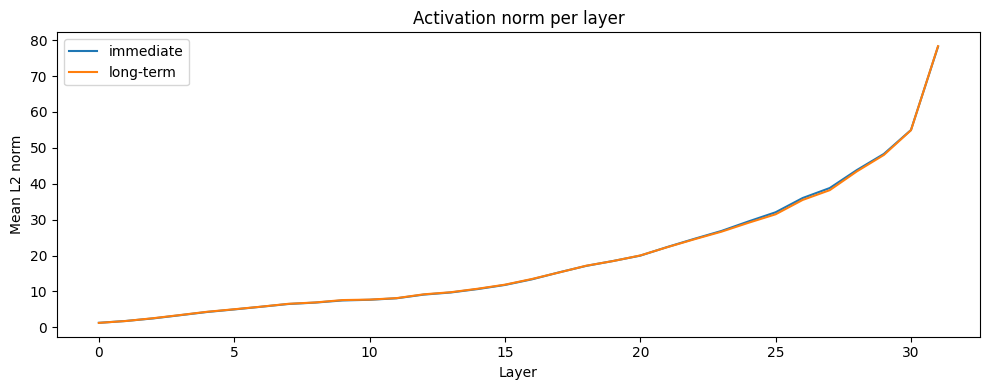

All values finite: OK


In [15]:
# Verification: per-layer L2 norm distribution — should be smooth
norms_imm = acts_immediate.norm(dim=-1).mean(dim=0).cpu()  # [n_layers]
norms_lt  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()

plt.figure(figsize=(10, 4))
plt.plot(norms_imm, label="immediate")
plt.plot(norms_lt,  label="long-term")
plt.xlabel("Layer")
plt.ylabel("Mean L2 norm")
plt.legend()
plt.title("Activation norm per layer")
plt.tight_layout()
plt.show()

# Verify finite values
assert torch.isfinite(acts_immediate).all(), "Non-finite values in acts_immediate"
assert torch.isfinite(acts_long_term).all(), "Non-finite values in acts_long_term"
print("All values finite: OK")

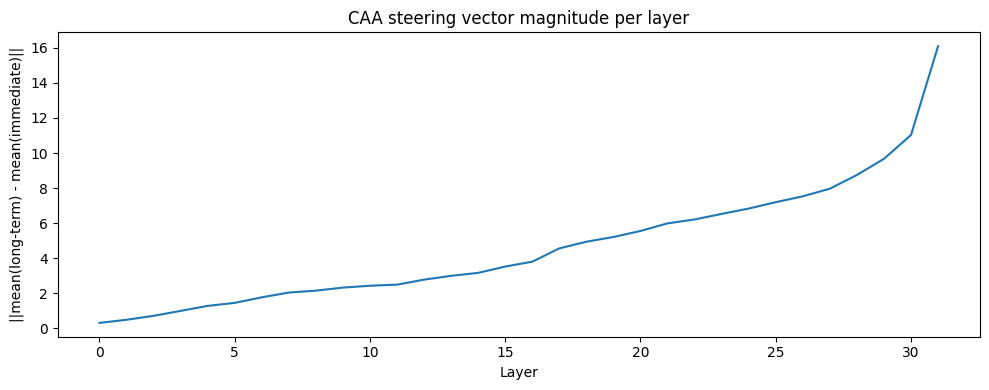

Peak CAA magnitude at layer 31 (of 32)


In [16]:
# Steering vector preview: mean activation difference per layer
# Norm should peak in middle-to-late layers (consistent with interpretability literature)
diff = (acts_long_term - acts_immediate).mean(dim=0)  # [n_layers, d_model]
diff_norms = diff.norm(dim=-1).cpu()

plt.figure(figsize=(10, 4))
plt.plot(diff_norms)
plt.xlabel("Layer")
plt.ylabel("||mean(long-term) - mean(immediate)||")
plt.title("CAA steering vector magnitude per layer")
plt.tight_layout()
plt.show()

peak_layer = diff_norms.argmax().item()
print(f"Peak CAA magnitude at layer {peak_layer} (of {runner.n_layers})")

## Section 2 — Implicit Dataset (300 pairs)

The explicit dataset above uses surface temporal keywords ("next 30 days", "10 years").
Here we repeat the extraction on the **implicit** dataset (300 pairs, no temporal keywords)
and compare side-by-side to see whether the temporal signal is surface-level or semantic.

In [17]:
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json")
IMPLICIT_OUT_DIR = get_experiment_dir() / "activation_extraction_implicit"
IMPLICIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

pairs_implicit, metadata_implicit = load_implicit_dataset(IMPLICIT_DATASET_PATH)
print(f"\nLoaded {len(pairs_implicit)} pairs")
print("\nFirst pair:")
for p in pairs_implicit[:1]:
    print(p)


Loaded 300 pairs

First pair:
{'id': 1, 'question': 'When the system fails, the first priority becomes', 'immediate': ' (A) containing the spreading damage before it escalates', 'long_term': ' (B) redesigning the architecture to prevent recurrence', 'category': 'crisis_vs_foundation'}


In [18]:
immediate_prompts_impl = [p["question"] + p["immediate"] for p in pairs_implicit]
long_term_prompts_impl  = [p["question"] + p["long_term"]  for p in pairs_implicit]
categories_impl         = [p["category"] for p in pairs_implicit]
print(f"immediate_prompts_impl[0]: {immediate_prompts_impl[0]!r}")
print(f"long_term_prompts_impl[0]:  {long_term_prompts_impl[0]!r}")
print(f"categories_impl[0]:         {categories_impl[0]!r}")
print(f"immediate_prompts_impl[1]: {immediate_prompts_impl[1]!r}")
print(f"long_term_prompts_impl[1]:  {long_term_prompts_impl[1]!r}")
print(f"categories_impl[1]:         {categories_impl[1]!r}")

immediate_prompts_impl[0]: 'When the system fails, the first priority becomes (A) containing the spreading damage before it escalates'
long_term_prompts_impl[0]:  'When the system fails, the first priority becomes (B) redesigning the architecture to prevent recurrence'
categories_impl[0]:         'crisis_vs_foundation'
immediate_prompts_impl[1]: 'The hospital administrator directs resources toward (B) stabilizing patients in critical condition'
long_term_prompts_impl[1]:  'The hospital administrator directs resources toward (A) training staff and upgrading medical equipment'
categories_impl[1]:         'crisis_vs_foundation'


In [19]:
acts_immediate_impl = extract_activations_for_prompts(runner, immediate_prompts_impl, desc="Implicit Immediate")
acts_long_term_impl = extract_activations_for_prompts(runner, long_term_prompts_impl, desc="Implicit Long-term")
print(f"Implicit immediate shape: {acts_immediate_impl.shape}")
print(f"Implicit long-term shape: {acts_long_term_impl.shape}")

assert torch.isfinite(acts_immediate_impl).all(), "Non-finite values in implicit immediate"
assert torch.isfinite(acts_long_term_impl).all(), "Non-finite values in implicit long-term"
print("All values finite: OK")

Implicit Long-term: 100%|██████████| 300/300 [00:36<00:00,  8.30it/s]


Implicit immediate shape: torch.Size([300, 32, 4096])
Implicit long-term shape: torch.Size([300, 32, 4096])
All values finite: OK


In [20]:
save_extraction_results(
    IMPLICIT_OUT_DIR,
    acts_immediate_impl,
    acts_long_term_impl,
    categories_impl,
    pairs_implicit,
    MODEL_NAME,
    IMPLICIT_DATASET_PATH,
)
print(f"Saved to: {IMPLICIT_OUT_DIR}")
for f in sorted(IMPLICIT_OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction_implicit
  activations_immediate.pt                  78.6 MB
  activations_long_term.pt                  78.6 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [21]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = IMPLICIT_OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1774365302
activations_long_term.pt last modified: 1774365311


## Section 3 — Side-by-Side Comparison

**Plot 1** — Activation norm per layer: do both datasets show the same growth pattern?
**Plot 2** — CAA vector magnitude per layer: does the peak shift when temporal keywords are absent?
**Plot 3** — Cosine similarity between the two CAA vectors at each layer: are the directions the same?

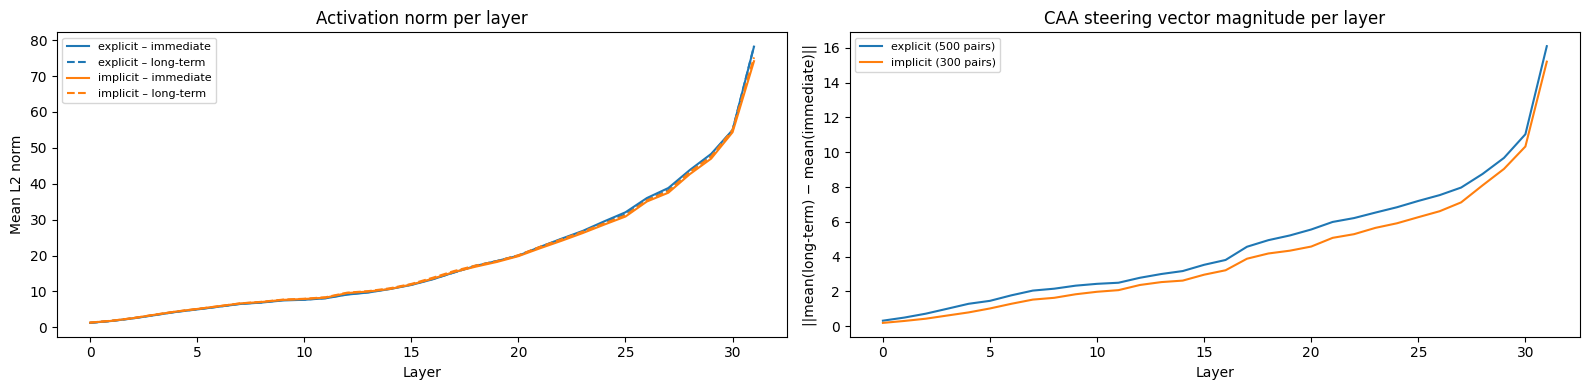

Explicit peak CAA layer: 31  (of 32)
Implicit peak CAA layer: 31  (of 32)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Plot 1: Activation norm per layer ---
ax = axes[0]
norms_imm_expl = acts_immediate.norm(dim=-1).mean(dim=0).cpu()
norms_lt_expl  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()
norms_imm_impl = acts_immediate_impl.norm(dim=-1).mean(dim=0).cpu()
norms_lt_impl  = acts_long_term_impl.norm(dim=-1).mean(dim=0).cpu()

ax.plot(norms_imm_expl, label="explicit – immediate",  color="tab:blue",   linestyle="-")
ax.plot(norms_lt_expl,  label="explicit – long-term",  color="tab:blue",   linestyle="--")
ax.plot(norms_imm_impl, label="implicit – immediate",  color="tab:orange",  linestyle="-")
ax.plot(norms_lt_impl,  label="implicit – long-term",  color="tab:orange",  linestyle="--")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 norm")
ax.set_title("Activation norm per layer")
ax.legend(fontsize=8)

# --- Plot 2: CAA vector magnitude per layer ---
ax = axes[1]
diff_expl = (acts_long_term - acts_immediate).mean(dim=0)          # [n_layers, d_model]
diff_impl = (acts_long_term_impl - acts_immediate_impl).mean(dim=0)
diff_norms_expl = diff_expl.norm(dim=-1).cpu()
diff_norms_impl = diff_impl.norm(dim=-1).cpu()

ax.plot(diff_norms_expl, label="explicit (500 pairs)", color="tab:blue")
ax.plot(diff_norms_impl, label="implicit (300 pairs)", color="tab:orange")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("CAA steering vector magnitude per layer")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

peak_expl = diff_norms_expl.argmax().item()
peak_impl = diff_norms_impl.argmax().item()
print(f"Explicit peak CAA layer: {peak_expl}  (of {runner.n_layers})")
print(f"Implicit peak CAA layer: {peak_impl}  (of {runner.n_layers})")

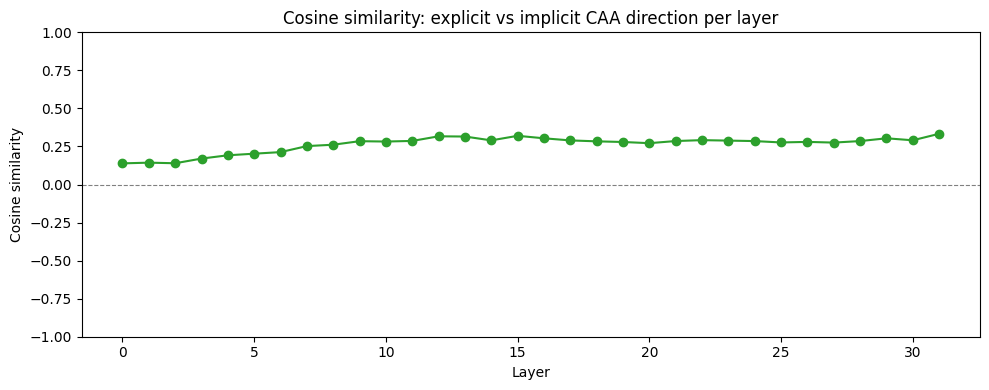

Mean cosine similarity (all layers): 0.264
Max  cosine similarity: 0.334  at layer 31
Min  cosine similarity: 0.139  at layer 0

Interpretation:
  ~1.0  → same temporal direction (semantic, keyword-independent)
  ~0.0  → unrelated directions (explicit driven by surface tokens)
  ~-1.0 → opposite directions (pathological / very different datasets)


In [23]:
# Cosine similarity between the two CAA directions at each layer
# High similarity → the model encodes the same temporal direction regardless of keywords
# Low similarity → explicit keywords drive a different (possibly surface-level) direction

cosine_sims = torch.nn.functional.cosine_similarity(
    diff_expl.float(), diff_impl.float(), dim=-1
).cpu()  # [n_layers]

plt.figure(figsize=(10, 4))
plt.plot(cosine_sims, marker="o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity: explicit vs implicit CAA direction per layer")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

print(f"Mean cosine similarity (all layers): {cosine_sims.mean():.3f}")
print(f"Max  cosine similarity: {cosine_sims.max():.3f}  at layer {cosine_sims.argmax().item()}")
print(f"Min  cosine similarity: {cosine_sims.min():.3f}  at layer {cosine_sims.argmin().item()}")
print()
print("Interpretation:")
print("  ~1.0  → same temporal direction (semantic, keyword-independent)")
print("  ~0.0  → unrelated directions (explicit driven by surface tokens)")
print("  ~-1.0 → opposite directions (pathological / very different datasets)")

# Part 2: Linear Probing (Week 2) 

**Why we're doing this:**
Week 1 showed the explicit-dataset CAA vector peaks at Layer 31 — a red flag.
Late layers in transformers typically handle surface token-prediction adjustments,
not abstract semantic content. The cosine similarity between explicit and implicit
CAA directions was only ~0.34, suggesting explicit dataset vectors are contaminated
by surface time-word heuristics.

**Approach (Geometry of Truth methodology):**
- Train a logistic regression probe per layer on the *implicit* dataset
- The layer with the highest test accuracy is where temporal content is encoded semantically
- Zero-shot evaluate those probes on the *explicit* dataset to test generalization
- Redefine the CAA steering vector from implicit dataset means at the best-probe layer

Activations are passed **in-memory** from Part 1 — no stale `.pt` file risk.

## Probing Setup

Configuration for Part 2. Activations are already in memory from Part 1:
- `acts_immediate_impl` / `acts_long_term_impl` — implicit (300 pairs)
- `acts_immediate` / `acts_long_term` — explicit (500 pairs)

In [24]:
OUT_DIR_PROBING = get_experiment_dir() / "week2_probing"
OUT_DIR_PROBING.mkdir(parents=True, exist_ok=True)

# In-memory handoff from Part 1 (no torch.load needed)
n_impl = acts_immediate_impl.shape[0]
n_expl = acts_immediate.shape[0]

N_LAYERS = 32
RANDOM_STATE = 42

print(f"Implicit activations: {acts_immediate_impl.shape} (n={n_impl})")
print(f"Explicit activations: {acts_immediate.shape} (n={n_expl})")
print("Ready for probing.")

Implicit activations: torch.Size([300, 32, 4096]) (n=300)
Explicit activations: torch.Size([500, 32, 4096]) (n=500)
Ready for probing.


## Section 4 — Per-Layer Linear Probing on Implicit Data

For each of the 32 layers:
- Stack immediate (label=0) and long-term (label=1) activations → [600, 4096]
- 80/20 stratified train/test split (random_state=42 for reproducibility)
- Fit LogisticRegression(C=0.1, max_iter=1000) — light L2 regularization per GoT paper
- Record test accuracy and save the trained probe to disk

**Why C=0.1?** The Geometry of Truth paper uses moderate regularization to prevent
overfitting and ensure the probe direction reflects a clean linear feature, not
dataset-specific noise.

In [25]:
# Build numpy arrays: X [n_impl*2, d_model] per layer, y [n_impl*2]
# Convert float16 → float32 for sklearn
X_impl_np = torch.cat([acts_immediate_impl, acts_long_term_impl], dim=0).float().numpy()
# X_impl_np shape: [600, 32, 4096] — index as [sample, layer, d_model]
y_impl = np.array([0]*n_impl + [1]*n_impl)  # 0=immediate, 1=long_term

layer_results = []

for layer in tqdm(range(N_LAYERS), desc="Probing layers"):
    X_layer = X_impl_np[:, layer, :]   # [600, 4096]

    X_train, X_test, y_train, y_test = train_test_split(
        X_layer, y_impl,
        test_size=0.2, random_state=RANDOM_STATE, stratify=y_impl
    )

    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe.fit(X_train, y_train)
    test_acc = probe.score(X_test, y_test)

    # Save probe to disk
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "wb") as f:
        pickle.dump(probe, f)

    layer_results.append({
        "layer": layer,
        "test_accuracy": test_acc,
        "n_train": len(y_train),
        "n_test": len(y_test),
    })

df_probes = pd.DataFrame(layer_results)
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)
# print(df_probes.to_string(index=False))

Probing layers: 100%|██████████| 32/32 [00:51<00:00,  1.61s/it]


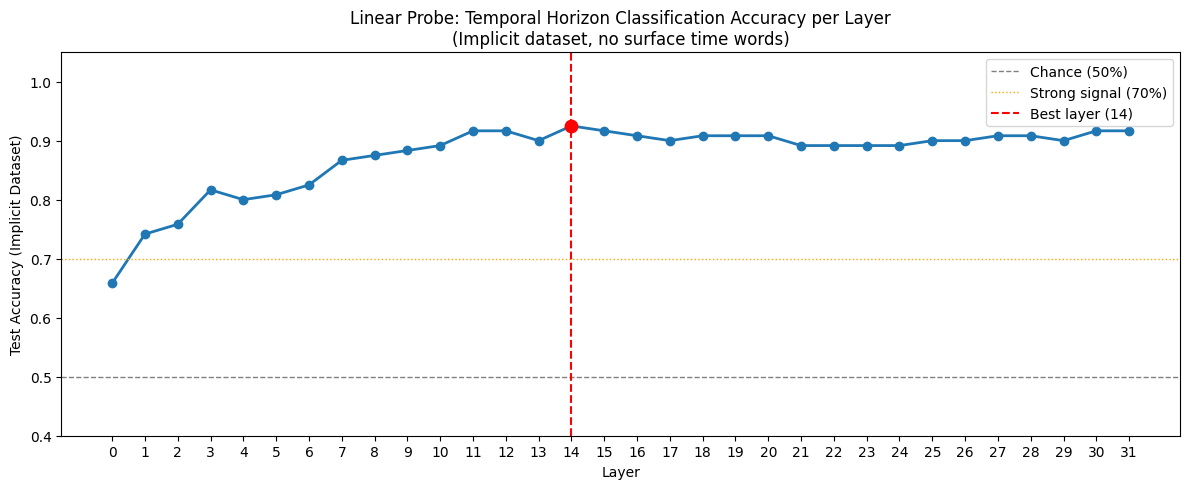


Best layer: 14  |  Test accuracy: 0.925

Top 5 layers:
 layer  test_accuracy  n_train  n_test
    14       0.925000      480     120
    11       0.916667      480     120
    12       0.916667      480     120
    15       0.916667      480     120
    30       0.916667      480     120


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"], marker="o", linewidth=2, color="tab:blue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")
ax.axhline(0.7, color="orange", linestyle=":", linewidth=1, label="Strong signal (70%)")

best_layer = int(df_probes.loc[df_probes["test_accuracy"].idxmax(), "layer"])
best_acc   = df_probes.loc[df_probes["test_accuracy"].idxmax(), "test_accuracy"]
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, label=f"Best layer ({best_layer})")
ax.scatter([best_layer], [best_acc], color="red", zorder=5, s=80)

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy (Implicit Dataset)")
ax.set_title("Linear Probe: Temporal Horizon Classification Accuracy per Layer\n(Implicit dataset, no surface time words)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_accuracy_per_layer.png", dpi=150)
plt.show()

print(f"\nBest layer: {best_layer}  |  Test accuracy: {best_acc:.3f}")
print("\nTop 5 layers:")
print(df_probes.nlargest(5, "test_accuracy").to_string(index=False))

In [27]:
# Freshness check — confirm probes were just written
for fname in ["probe_accuracies.csv", "probe_accuracy_per_layer.png"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

probe_accuracies.csv last modified: 1774365370
probe_accuracy_per_layer.png last modified: 1774365371


## Section 5 — Zero-Shot Cross-Dataset Generalization

We take the probes trained **only on implicit data** and evaluate them on the explicit
dataset — probes never saw any explicit time words during training.

**What this tells us:**
- High cross-dataset accuracy → the probe learned a genuinely semantic temporal direction
- Low cross-dataset accuracy → the probe learned something specific to the implicit dataset's
  linguistic patterns, not a universal temporal concept
- The difference between implicit test accuracy and cross-dataset accuracy measures
  how much of the temporal signal is surface-level vs. semantic

In [28]:
X_expl_np = torch.cat([acts_immediate, acts_long_term], dim=0).float().numpy()
y_expl    = np.array([0]*n_expl + [1]*n_expl)

cross_accs = []
for layer in tqdm(range(N_LAYERS), desc="Cross-dataset eval"):
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "rb") as f:
        probe = pickle.load(f)
    X_layer_expl = X_expl_np[:, layer, :]
    cross_acc = probe.score(X_layer_expl, y_expl)
    cross_accs.append(cross_acc)

df_probes["cross_dataset_accuracy"] = cross_accs
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)

Cross-dataset eval: 100%|██████████| 32/32 [00:00<00:00, 71.75it/s]


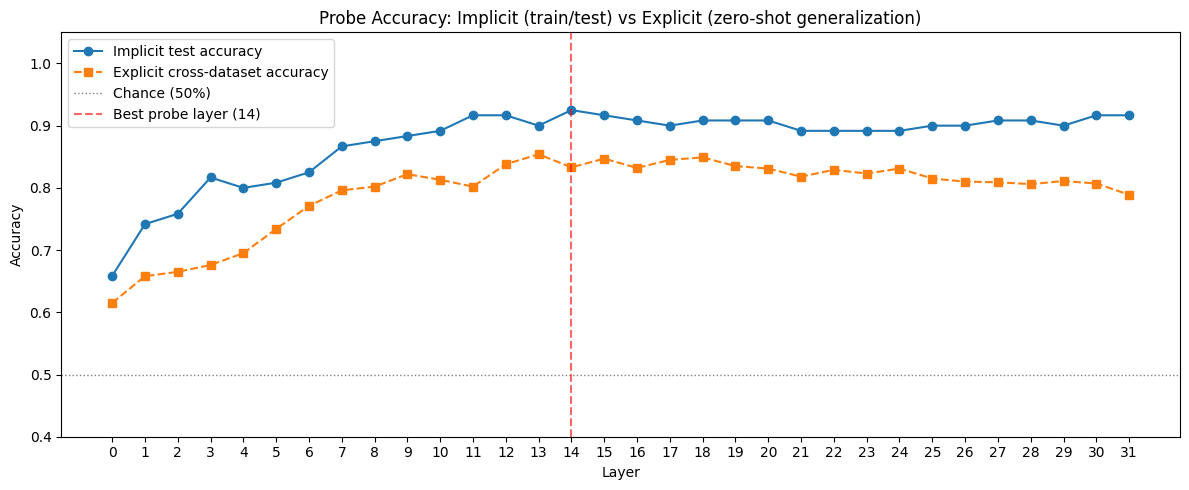


At best probe layer (14):
  Implicit test accuracy:          0.925
  Explicit cross-dataset accuracy: 0.833
  Generalization gap:              0.092


In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"],
        marker="o", label="Implicit test accuracy", color="tab:blue")
ax.plot(df_probes["layer"], df_probes["cross_dataset_accuracy"],
        marker="s", label="Explicit cross-dataset accuracy", color="tab:orange", linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Chance (50%)")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Best probe layer ({best_layer})")

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Probe Accuracy: Implicit (train/test) vs Explicit (zero-shot generalization)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_generalization.png", dpi=150)
plt.show()

print(f"\nAt best probe layer ({best_layer}):")
print(f"  Implicit test accuracy:          {df_probes.loc[best_layer, 'test_accuracy']:.3f}")
print(f"  Explicit cross-dataset accuracy: {df_probes.loc[best_layer, 'cross_dataset_accuracy']:.3f}")
generalization_gap = (df_probes.loc[best_layer, 'test_accuracy']
                      - df_probes.loc[best_layer, 'cross_dataset_accuracy'])
print(f"  Generalization gap:              {generalization_gap:.3f}")

## Section 6 — Redefine the CAA Steering Vector

We now compute the Contrastive Activation Addition vector strictly from the
**implicit** dataset means at the best probe layer.

This is the principled choice because:
1. The best probe layer is where temporal content is most linearly separable
2. The implicit dataset has no surface time words, so the direction captures
   *semantic* temporal reasoning rather than surface token patterns
3. Unit-normalisation makes the vector scale-agnostic for steering strength control

This replaces the Layer 31 explicit-dataset vector from Week 1.

Best probe layer: 14
Raw CAA vector norm at layer 14: 2.6210
Unit vector norm: 1.000000


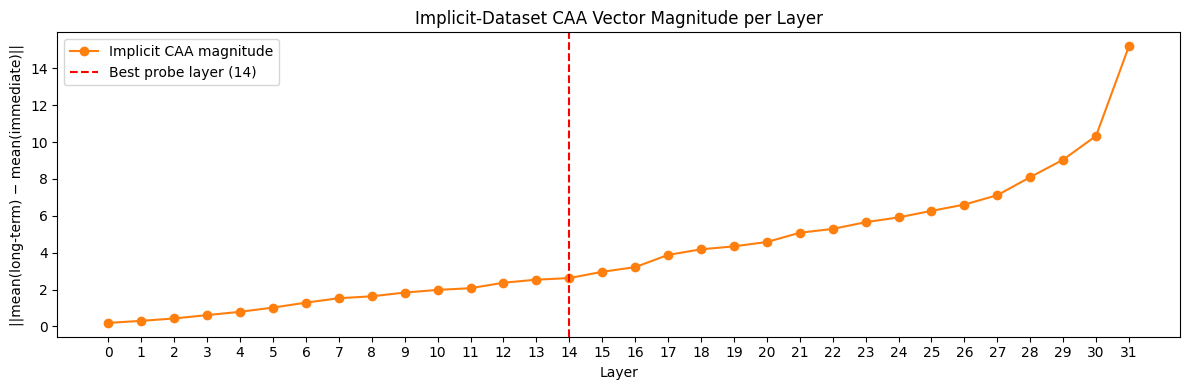


Saved to: /content/temporal-awareness/out/experiments/week2_probing
  implicit_caa_magnitude.png                     67.0 KB
  implicit_caa_vector_unit.npy                   16.5 KB
  implicit_caa_vector_unit.pt                    18.1 KB
  probe_accuracies.csv                           1.1 KB
  probe_accuracy_per_layer.png                   82.3 KB
  probe_generalization.png                       90.6 KB
  probe_layer_00.pkl                             33.5 KB
  probe_layer_01.pkl                             33.5 KB
  probe_layer_02.pkl                             33.5 KB
  probe_layer_03.pkl                             33.5 KB
  probe_layer_04.pkl                             33.5 KB
  probe_layer_05.pkl                             33.5 KB
  probe_layer_06.pkl                             33.5 KB
  probe_layer_07.pkl                             33.5 KB
  probe_layer_08.pkl                             33.5 KB
  probe_layer_09.pkl                             33.5 KB
  probe_layer_10.pkl

In [30]:
# Implicit CAA vector at every layer (for reference) and at the best layer (for steering)
diff_impl_all = (acts_long_term_impl.float() - acts_immediate_impl.float()).mean(dim=0)  # [32, 4096]
caa_norms_impl = diff_impl_all.norm(dim=-1)  # [32]

# Select best-probe layer
caa_vec_raw = diff_impl_all[best_layer]                   # [4096]
caa_vec_unit = caa_vec_raw / caa_vec_raw.norm().clamp(min=1e-8)  # unit norm

print(f"Best probe layer: {best_layer}")
print(f"Raw CAA vector norm at layer {best_layer}: {caa_vec_raw.norm():.4f}")
print(f"Unit vector norm: {caa_vec_unit.norm():.6f}")

# Plot CAA magnitude per layer for implicit dataset
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(caa_norms_impl.numpy(), marker="o", color="tab:orange", label="Implicit CAA magnitude")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5,
           label=f"Best probe layer ({best_layer})")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("Implicit-Dataset CAA Vector Magnitude per Layer")
ax.legend()
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "implicit_caa_magnitude.png", dpi=150)
plt.show()

# Save the steering vector
torch.save(caa_vec_unit, OUT_DIR_PROBING / "implicit_caa_vector_unit.pt")
np.save(OUT_DIR_PROBING / "implicit_caa_vector_unit.npy", caa_vec_unit.numpy())

# Save metadata
meta = {
    "best_probe_layer": best_layer,
    "implicit_test_accuracy": float(df_probes.loc[best_layer, "test_accuracy"]),
    "explicit_cross_accuracy": float(df_probes.loc[best_layer, "cross_dataset_accuracy"]),
    "raw_caa_norm": float(caa_vec_raw.norm()),
    "vector_shape": list(caa_vec_unit.shape),
    "dataset": "temporal_scope_implicit_expanded_300",
    "n_implicit_pairs": n_impl,
    "note": "Unit-norm implicit CAA vector at best-probe layer. Use for Week 3 steering."
}
with open(OUT_DIR_PROBING / "steering_vector_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nSaved to: {OUT_DIR_PROBING}")
for p in sorted(OUT_DIR_PROBING.iterdir()):
    print(f"  {p.name:45s}  {p.stat().st_size/1e3:.1f} KB")

In [31]:
# Freshness check — confirm steering vector was just written
for fname in ["implicit_caa_vector_unit.pt", "steering_vector_meta.json"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

implicit_caa_vector_unit.pt last modified: 1774365378
steering_vector_meta.json last modified: 1774365379


## Summary

| Metric | Value |
|--------|-------|
| Best probe layer | `best_layer` |
| Implicit test accuracy | X.XXX |
| Explicit cross-dataset accuracy | X.XXX |
| Generalization gap | X.XXX |
| New CAA vector source | Implicit dataset, best-probe layer |
| Saved vector | `week2_probing/implicit_caa_vector_unit.pt` |

**Interpretation:**
- If cross-dataset acc >> 50%: the temporal direction generalizes across datasets —
  it's a semantic feature, not surface-level memorization
- If cross-dataset acc ≈ implicit test acc: the two datasets share the same temporal
  subspace — strongest evidence for a genuine internal temporal representation
- The new steering vector should produce more coherent, semantically meaningful
  temporal shifts than the Layer 31 explicit-CAA vector from Week 1

**Next Steps (Week 3):**
- Use `implicit_caa_vector_unit.pt` at layer `best_layer` for steering experiments
- Test on neutral prompts with the corrected strength range [1, 3, 7, 15]
- Compare before/after outputs systematically across temporal categories

─── # Part 3: CAA Steering (Week 3) ───

**Goal:** Verify that the CAA direction found in Week 2 actually shifts generation toward longer or shorter temporal horizons.

**In-memory handoff:** activations and the `caa_vec_unit` vector are already computed above — no Drive reload needed.

**What we do:**
1. Compute per-layer CAA unit vectors (using implicit activations from Part 1)
2. Sweep prompts × strengths × conditions (baseline / long-term / short-term)
3. Optionally run a quantitative binary-choice logprob sweep
4. All behaviour is controlled by the **config cell immediately below**

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# WEEK 3 CONFIGURATION — edit this cell to control the steering experiment
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Steering mode ─────────────────────────────────────────────────────────
# "single" → steer one layer only  (uses W3_STEER_LAYER)
# "multi"  → steer multiple layers simultaneously
W3_STEERING_MODE = "single"

# ── 2. Layer selection ───────────────────────────────────────────────────────
# [SINGLE] Which layer to steer. Defaults to best_layer from Week 2.
W3_STEER_LAYER = 24        # override with any int, e.g. 14

# [MULTI] How to pick layers:
#   "manual" → use the list in W3_STEER_LAYERS below
#   "top_k"  → auto-select W3_TOP_K_LAYERS layers with the highest raw CAA norm
W3_MULTI_LAYER_MODE = "top_k"
W3_STEER_LAYERS     = [10, 12, 14]   # used only when W3_MULTI_LAYER_MODE = "manual"
W3_TOP_K_LAYERS     = 3              # used only when W3_MULTI_LAYER_MODE = "top_k"

# ── 3. Steering strengths ────────────────────────────────────────────────────
# Choose ONE of three modes (set the others to None):
#
# MODE A — fraction of mean residual norm at W3_STEER_LAYER
#   0.10 = 10% of typical activation magnitude; 0.40 is a strong push
W3_STRENGTHS_FRAC = [0.05, 0.10, 0.20, 0.40]

# MODE B — multiple of the raw CAA vector norm at W3_STEER_LAYER
#   1.0 = exact CAA magnitude, 1.73 = stronger, 0.32 = weaker
#   Set to a list to activate; set to None to use MODE A instead
W3_STRENGTHS_CAA_MULTIPLE = None     # e.g. [0.32, 0.75, 1.0, 1.73]

# MODE C — absolute values (exact floats added to the residual stream)
#   Set to a list to activate; overrides both MODE A and MODE B
W3_STRENGTHS_ABSOLUTE = None         # e.g. [5.0, 10.0, 20.0]

# ── 4. Prompt selection ───────────────────────────────────────────────────────
# All available prompts (copy indices into W3_SELECTED_PROMPTS to pick a subset):
#
#   NEUTRAL (open-ended decision stems, no temporal cues):
#     [1]  'When managing a new project, my primary focus is:'
#     [2]  'The best way to allocate a sudden surplus of budget is:'
#     [3]  'When building a team, the most important quality to look for is:'
#     [4]  'In the face of an unexpected setback, the right response is:'
#     [5]  'When developing a new skill, the most effective approach is:'
#
#   FORCING (direct preference completions):
#     [6]  'What matters most to me is:'
#     [7]  'If I could only focus on one thing, it would be:'
#     [8]  'Above all else, I value:'
#     [9]  'The thing that guides every decision I make is:'
#     [10] 'When I think about what I want, the answer is always:'
#
# W3_PROMPT_SET: "neutral" (1-5), "forcing" (6-10), or "both" (all 10)
W3_PROMPT_SET = "both"

# W3_SELECTED_PROMPTS: override W3_PROMPT_SET with specific indices, or None.
# e.g. [1, 6] → first neutral + first forcing only (fast: 2 prompts × 9 conditions)
W3_SELECTED_PROMPTS = [8]

# ── 5. Generation settings ────────────────────────────────────────────────────
W3_TEMPERATURE = 0.3      # 0 = greedy (deterministic); higher = more varied
W3_MAX_TOKENS  = 120      # max new tokens per generation

# ── 6. Binary choice evaluation ───────────────────────────────────────────────
W3_RUN_BINARY_CHOICE = True   # set False to skip the logprob P(long-term) sweep

# ── Display (no need to edit) ─────────────────────────────────────────────────
print("Week 3 configuration:")
print(f"  Steering mode       : {W3_STEERING_MODE}")
if W3_STEERING_MODE == "single":
    print(f"  Steer layer         : {W3_STEER_LAYER}")
else:
    print(f"  Multi-layer mode    : {W3_MULTI_LAYER_MODE}")
    if W3_MULTI_LAYER_MODE == "manual":
        print(f"  Steer layers        : {W3_STEER_LAYERS}")
    else:
        print(f"  Top-k layers        : {W3_TOP_K_LAYERS}")
if W3_STRENGTHS_ABSOLUTE is not None:
    print(f"  Strength mode       : MODE C (absolute) → {W3_STRENGTHS_ABSOLUTE}")
elif W3_STRENGTHS_CAA_MULTIPLE is not None:
    print(f"  Strength mode       : MODE B (CAA multiple) → {W3_STRENGTHS_CAA_MULTIPLE}× raw CAA norm")
else:
    print(f"  Strength mode       : MODE A (frac of resid norm) → {W3_STRENGTHS_FRAC}")
_ps = W3_SELECTED_PROMPTS if W3_SELECTED_PROMPTS else f"set={W3_PROMPT_SET}"
print(f"  Prompts             : {_ps}")
print(f"  Temperature         : {W3_TEMPERATURE}  |  Max tokens: {W3_MAX_TOKENS}")
print(f"  Binary choice       : {W3_RUN_BINARY_CHOICE}")

Week 3 configuration:
  Steering mode       : single
  Steer layer         : 24
  Strength mode       : MODE A (frac of resid norm) → [0.05, 0.1, 0.2, 0.4]
  Prompts             : [8]
  Temperature         : 0.3  |  Max tokens: 120
  Binary choice       : True


## Section 7 — CAA Vectors (In-Memory)

Build per-layer CAA unit vectors from the implicit activations already in memory.
No Drive reload needed — `acts_immediate_impl` / `acts_long_term_impl` are passed directly from Part 1.

In [33]:
from src.inference.interventions import steering as make_steering_intervention

# ── Per-layer CAA unit vectors (all layers) ───────────────────────────────────
_acts_imm = acts_immediate_impl.float()
_acts_lt  = acts_long_term_impl.float()
n_w3_layers = _acts_imm.shape[1]

w3_caa_units    = {}    # layer → np.ndarray [d_model], float32
w3_caa_raw_norm = {}    # layer → float  (used for top-k selection and MODE B strengths)

for L in range(n_w3_layers):
    raw = (_acts_lt[:, L, :] - _acts_imm[:, L, :]).mean(dim=0)
    w3_caa_raw_norm[L] = float(raw.norm())
    w3_caa_units[L]    = (raw / raw.norm().clamp(min=1e-8)).numpy().astype("float32")

print(f"CAA unit vectors computed for all {n_w3_layers} layers.")

# ── Resolve active steering layers from config ────────────────────────────────
if W3_STEERING_MODE == "multi":
    if W3_MULTI_LAYER_MODE == "top_k":
        _sorted_by_norm = sorted(w3_caa_raw_norm, key=w3_caa_raw_norm.__getitem__, reverse=True)
        _steer_layers_active = sorted(_sorted_by_norm[:W3_TOP_K_LAYERS])
        print(f"\nTop-{W3_TOP_K_LAYERS} layers by raw CAA norm → {_steer_layers_active}")
    else:
        _steer_layers_active = W3_STEER_LAYERS
        print(f"\nManual multi-layer selection → {_steer_layers_active}")
else:
    _steer_layers_active = [W3_STEER_LAYER]
    print(f"\nSingle-layer mode → layer {W3_STEER_LAYER}")

# ── Print per-layer norms, highlight active layers ────────────────────────────
print(f"\nPer-layer raw CAA norms:")
for L in range(n_w3_layers):
    marker = " ◄ ACTIVE" if L in _steer_layers_active else ""
    print(f"  Layer {L:2d}: {w3_caa_raw_norm[L]:.4f}{marker}")

# ── Resolve strengths (priority: MODE C > MODE B > MODE A) ───────────────────
_ref_layer_acts  = _acts_imm[:, W3_STEER_LAYER, :]
_mean_resid_norm = float(_ref_layer_acts.norm(dim=-1).mean())
_caa_norm_ref    = w3_caa_raw_norm[W3_STEER_LAYER]

if W3_STRENGTHS_ABSOLUTE is not None:
    W3_STRENGTHS   = W3_STRENGTHS_ABSOLUTE
    _strength_desc = f"MODE C (absolute): {W3_STRENGTHS}"
elif W3_STRENGTHS_CAA_MULTIPLE is not None:
    W3_STRENGTHS   = [round(m * _caa_norm_ref, 4) for m in W3_STRENGTHS_CAA_MULTIPLE]
    _strength_desc = (
        f"MODE B (×CAA norm={_caa_norm_ref:.3f}): "
        f"{W3_STRENGTHS_CAA_MULTIPLE} → {W3_STRENGTHS}"
    )
else:
    W3_STRENGTHS   = [round(f * _mean_resid_norm, 3) for f in W3_STRENGTHS_FRAC]
    _strength_desc = (
        f"MODE A (frac of resid norm={_mean_resid_norm:.3f}): "
        f"{W3_STRENGTHS_FRAC} → {W3_STRENGTHS}"
    )

print(f"\nStrength resolution: {_strength_desc}")
print(f"  CAA raw norm at layer {W3_STEER_LAYER}: {_caa_norm_ref:.4f}")
print(f"  Mean resid norm at layer {W3_STEER_LAYER}: {_mean_resid_norm:.3f}")
print(f"  Final W3_STRENGTHS: {W3_STRENGTHS}")

# ── Save CAA vector at W3_STEER_LAYER ─────────────────────────────────────────
W3_OUT_DIR = get_experiment_dir() / "week3_steering"
W3_OUT_DIR.mkdir(parents=True, exist_ok=True)
_caa_tensor = torch.tensor(w3_caa_units[W3_STEER_LAYER])
torch.save(_caa_tensor, W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.pt")
np.save(W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.npy", w3_caa_units[W3_STEER_LAYER])
print(f"\nSaved CAA vector (layer {W3_STEER_LAYER}) → {W3_OUT_DIR}")

CAA unit vectors computed for all 32 layers.

Single-layer mode → layer 24

Per-layer raw CAA norms:
  Layer  0: 0.1908
  Layer  1: 0.3018
  Layer  2: 0.4311
  Layer  3: 0.6127
  Layer  4: 0.7926
  Layer  5: 1.0202
  Layer  6: 1.2893
  Layer  7: 1.5289
  Layer  8: 1.6318
  Layer  9: 1.8356
  Layer 10: 1.9790
  Layer 11: 2.0731
  Layer 12: 2.3687
  Layer 13: 2.5346
  Layer 14: 2.6210
  Layer 15: 2.9616
  Layer 16: 3.2150
  Layer 17: 3.8787
  Layer 18: 4.1795
  Layer 19: 4.3416
  Layer 20: 4.5777
  Layer 21: 5.0799
  Layer 22: 5.2879
  Layer 23: 5.6521
  Layer 24: 5.9125 ◄ ACTIVE
  Layer 25: 6.2664
  Layer 26: 6.6079
  Layer 27: 7.1163
  Layer 28: 8.0966
  Layer 29: 9.0425
  Layer 30: 10.3320
  Layer 31: 15.2002

Strength resolution: MODE A (frac of resid norm=28.607): [0.05, 0.1, 0.2, 0.4] → [1.43, 2.861, 5.721, 11.443]
  CAA raw norm at layer 24: 5.9125
  Mean resid norm at layer 24: 28.607
  Final W3_STRENGTHS: [1.43, 2.861, 5.721, 11.443]

Saved CAA vector (layer 24) → /content/tempo

## Section 8 — Prompt Library & Selection

Two prompt sets:
- **Neutral** (5): open-ended decision stems, no temporal keywords — tests whether steering shifts framing organically
- **Forcing** (5): direct preference completions — cleaner window into which horizon is activated

`W3_SELECTED_PROMPTS` (config cell) overrides `W3_PROMPT_SET` if set.

In [34]:
_NEUTRAL_PROMPTS = [
    # ── Neutral decision-making (no temporal cues) ──────────────────────────
    'When managing a new project, my primary focus is:',
    'The best way to allocate a sudden surplus of budget is:',
    'When building a team, the most important quality to look for is:',
    'In the face of an unexpected setback, the right response is:',
    'When developing a new skill, the most effective approach is:',
]

_FORCING_PROMPTS = [
    # ── Direct preference-forcing ────────────────────────────────────────────
    'What matters most to me is:',
    'If I could only focus on one thing, it would be:',
    'Above all else, I value:',
    'The thing that guides every decision I make is:',
    'When I think about what I want, the answer is always:',
]

# ── All prompts with tags (1-indexed to match W3_SELECTED_PROMPTS) ────────────
_ALL_PROMPTS = (
    [{'text': p, 'set': 'neutral', 'idx': i + 1}      for i, p in enumerate(_NEUTRAL_PROMPTS)]
    + [{'text': p, 'set': 'forcing', 'idx': i + 6}    for i, p in enumerate(_FORCING_PROMPTS)]
)

# ── Apply config selection ────────────────────────────────────────────────────
if W3_SELECTED_PROMPTS is not None:
    _idx_set = set(W3_SELECTED_PROMPTS)
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['idx'] in _idx_set]
elif W3_PROMPT_SET == "neutral":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'neutral']
elif W3_PROMPT_SET == "forcing":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'forcing']
else:  # "both"
    W3_ACTIVE_PROMPTS = _ALL_PROMPTS

print(f"Active prompts ({len(W3_ACTIVE_PROMPTS)}):")
for p in W3_ACTIVE_PROMPTS:
    print(f"  [{p['idx']:2d}] [{p['set']}] {p['text']}")

Active prompts (1):
  [ 8] [forcing] Above all else, I value:


## Section 9 — Steering Sweep

Runs the sweep according to `W3_STEERING_MODE`:

- **single**: adds `caa_unit[W3_STEER_LAYER] * strength` to the residual stream at one layer
- **multi**: adds `caa_unit[L] * strength` at *each* layer in `W3_STEER_LAYERS` at **full** strength (not divided — splitting the budget weakens the signal)

Positive strength → long-term direction; negative → short-term.

In [42]:
def _generate_with_hooks(prompt: str, hook_pairs: list) -> str:
    """Generate text with custom forward hooks active (TransformerLens)."""
    formatted  = runner.apply_chat_template(prompt)
    input_ids  = runner._backend.encode(formatted)
    prompt_len = input_ids.shape[1]
    gen_kwargs = {
        "max_new_tokens":    W3_MAX_TOKENS,
        "do_sample":         W3_TEMPERATURE > 0,
        "temperature":       W3_TEMPERATURE,
        "stop_at_eos":       True,
        "verbose":           False,
        "use_past_kv_cache": False,  # must be False when hooks are active
    }
    with torch.no_grad():
        with runner._model.hooks(fwd_hooks=hook_pairs):
            output_ids = runner._model.generate(input_ids, **gen_kwargs)
    return runner._backend.decode(output_ids[0, prompt_len:]).strip()


def _make_hooks(layers: list[int], direction: float, strength: float) -> list:
    """Build hook pairs for residual-stream addition at each specified layer."""
    pairs = []
    for L in layers:
        vec = torch.tensor(
            w3_caa_units[L] * direction * strength,
            dtype=runner.dtype,
            device=runner.device,
        )
        pairs.append(
            (f"blocks.{L}.hook_resid_post", lambda act, hook=None, v=vec: act + v)
        )
    return pairs


# ── Condition list ─────────────────────────────────────────────────────────────
_steer_layers_active = (
    W3_STEER_LAYERS if W3_STEERING_MODE == "multi" else [W3_STEER_LAYER]
)

W3_CONDITIONS = (
    [("baseline", None)]
    + [(f"LT_{s}",  (+1.0, s)) for s in W3_STRENGTHS]
    + [(f"ST_{s}",  (-1.0, s)) for s in W3_STRENGTHS]
)

# ── Run sweep ──────────────────────────────────────────────────────────────────
W3_RESULTS = []
total = len(W3_ACTIVE_PROMPTS) * len(W3_CONDITIONS)
done  = 0

for pdata in W3_ACTIVE_PROMPTS:
    entry = {"prompt": pdata["text"], "set": pdata["set"], "idx": pdata["idx"], "conditions": {}}

    for label, args in W3_CONDITIONS:
        if args is None:
            # Baseline: generate with no hooks but KV cache disabled
            # (runner.generate uses KV cache which triggers a TransformerLens
            #  dtype mismatch: cached keys are float32 vs float16 queries)
            text = _generate_with_hooks(pdata["text"], [])
        else:
            direction, strength = args
            hooks = _make_hooks(_steer_layers_active, direction, strength)
            text  = _generate_with_hooks(pdata["text"], hooks)

        entry["conditions"][label] = text.strip()
        done += 1
        print(f"  [{done:3d}/{total}] prompt={pdata['idx']:2d} ({pdata['set']})  {label}")

    W3_RESULTS.append(entry)

print(f"\nSweep complete ({W3_STEERING_MODE}-layer, layers={_steer_layers_active}).")

RuntimeError: expected scalar type Half but found Float

## Section 10 — Results Display

In [36]:
import json
from IPython.display import display, Markdown

_NL = chr(10)
_mode_label = (
    f"Single-layer L{W3_STEER_LAYER}"
    if W3_STEERING_MODE == "single"
    else f"Multi-layer {_steer_layers_active}"
)


def _abbrev(text: str, n: int = 240) -> str:
    text = " ".join(text.split()).replace("|", "/")
    return text if len(text) <= n else text[:n].rsplit(" ", 1)[0] + "..."


def _render_entry(entry: dict) -> str:
    cond = entry["conditions"]
    rows = [
        "| Condition | Strength | Completion |",
        "|-----------|:--------:|------------|",
        f"| **Baseline** | — | {_abbrev(cond['baseline'])} |",
    ]
    for s in W3_STRENGTHS:
        lt = _abbrev(cond.get(f"LT_{s}", "(missing)"))
        st = _abbrev(cond.get(f"ST_{s}", "(missing)"))
        rows.append(f"| ↑ Long-term  | +{s} | {lt} |")
        rows.append(f"| ↓ Short-term | −{s} | {st} |")
    header = (
        f"### [{entry['set']}] Prompt {entry['idx']}{_NL}{_NL}"
        f"> {entry['prompt']}{_NL}{_NL}"
    )
    return header + _NL.join(rows)


print(f"{'=' * 60}")
print(f"STEERING RESULTS  —  {_mode_label}")
print(f"{'=' * 60}")
for entry in W3_RESULTS:
    display(Markdown(_render_entry(entry)))
    print()

# ── Save to JSON ───────────────────────────────────────────────────────────────
_save_name = (
    f"steering_results_single_L{W3_STEER_LAYER}.json"
    if W3_STEERING_MODE == "single"
    else f"steering_results_multi_{'_'.join(str(l) for l in _steer_layers_active)}.json"
)
_save_data = {
    "mode":              W3_STEERING_MODE,
    "steer_layers":      _steer_layers_active,
    "strengths":         W3_STRENGTHS,
    "strengths_frac":    W3_STRENGTHS_FRAC,
    "mean_resid_norm":   round(_mean_resid_norm, 4),
    "temperature":       W3_TEMPERATURE,
    "results":           W3_RESULTS,
}
with open(W3_OUT_DIR / _save_name, "w") as f:
    json.dump(_save_data, f, indent=2)
print(f"Saved: {W3_OUT_DIR / _save_name}")

STEERING RESULTS  —  Single-layer L24
Saved: /content/temporal-awareness/out/experiments/week3_steering/steering_results_single_L24.json


## Section 11 — Binary Choice Logprob Sweep (Quantitative)

Each question offers an **immediate** option (A) and a **long-term** option (B).
We measure the raw logprob of the branch token `(A)` vs `(B)` — no text parsing needed.

`P(long-term)` = softmax over the two logprobs.

**Design note:** These questions are deliberately more **balanced** than the previous version.
Most prior questions had baseline P(LT) > 0.9, leaving no headroom to observe steering.
Questions here are chosen so the model is closer to 50/50 at baseline — making the
steering signal visible even at moderate strengths.

Controlled by `W3_RUN_BINARY_CHOICE` in the config cell.

In [ ]:
if not W3_RUN_BINARY_CHOICE:
    print("W3_RUN_BINARY_CHOICE=False — skipping binary choice sweep.")
else:
    import math
    from src.binary_choice import BinaryChoiceRunner

    # Upgrade runner in-place — no model reload
    runner.__class__ = BinaryChoiceRunner

    # ── Binary choice questions ───────────────────────────────────────────────
    # A = immediate,  B = long-term  (consistent across all questions).
    # Chosen for near-50/50 baseline so that steering signal has room to show.
    BINARY_QUESTIONS = [
        {
            "question": (
                "A startup facing a cash crunch should:\n"
                "(A) Cut costs immediately to survive the next 90 days\n"
                "(B) Stay the course on the long-term product roadmap"
            ),
        },
        {
            "question": (
                "A student with an exam tomorrow and a project due in three months should tonight:\n"
                "(A) Study hard for tomorrow's exam\n"
                "(B) Work on the long-term project instead"
            ),
        },
        {
            "question": (
                "When allocating a team's sprint capacity, the better choice is:\n"
                "(A) Fixing the bug that is breaking users right now\n"
                "(B) Rewriting the architecture to prevent future bugs"
            ),
        },
        {
            "question": (
                "After an unexpected setback, the wiser first move is:\n"
                "(A) Patch the immediate damage quickly and move on\n"
                "(B) Pause, reflect, and redesign to avoid recurrence"
            ),
        },
        {
            "question": (
                "When managing personal finances, it is more important to:\n"
                "(A) Cover this month's bills and feel stable now\n"
                "(B) Invest consistently for compounding returns over decades"
            ),
        },
        {
            "question": (
                "A new manager joining a struggling team should first:\n"
                "(A) Address the most visible complaints to win quick trust\n"
                "(B) Diagnose root causes and build a culture that lasts"
            ),
        },
    ]

    CHOICE_PREFIX = "\nPlease respond only 'A' or 'B' \nThe better choice is: "
    LABELS = ("A", "B")   # A = immediate, B = long-term

    def _softmax2(lp_a: float, lp_b: float) -> tuple:
        m = max(lp_a, lp_b)
        ea, eb = math.exp(lp_a - m), math.exp(lp_b - m)
        s = ea + eb
        return ea / s, eb / s

    def _p_lt(question: str, hook_pairs: list = None) -> float:
        """Return P(long-term) = P(B) for the question, with optional hooks."""
        if hook_pairs:
            with runner._model.hooks(fwd_hooks=hook_pairs):
                result = runner.choose(
                    prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
                )
        else:
            result = runner.choose(
                prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
            )
        lp_a, lp_b = result.divergent_logprobs
        _, p = _softmax2(lp_a, lp_b)
        return p

    # ── Build conditions for binary choice ────────────────────────────────────
    BC_CONDITIONS = (
        [("baseline", [])]
        + [(f"LT_{s}", _make_hooks(_steer_layers_active, +1.0, s)) for s in W3_STRENGTHS]
        + [(f"ST_{s}", _make_hooks(_steer_layers_active, -1.0, s)) for s in W3_STRENGTHS]
    )

    bc_results = []
    total_bc = len(BINARY_QUESTIONS) * len(BC_CONDITIONS)
    done_bc  = 0

    for qi, q in enumerate(BINARY_QUESTIONS):
        row = {"question": q["question"], "conditions": {}}
        for label, hooks in BC_CONDITIONS:
            p = _p_lt(q["question"], hooks or None)
            row["conditions"][label] = round(p, 4)
            done_bc += 1
            print(f"  [{done_bc:3d}/{total_bc}] Q{qi + 1} {label:<18}  P(LT)={p:.3f}")
        bc_results.append(row)

    print("\nBinary choice sweep complete.")

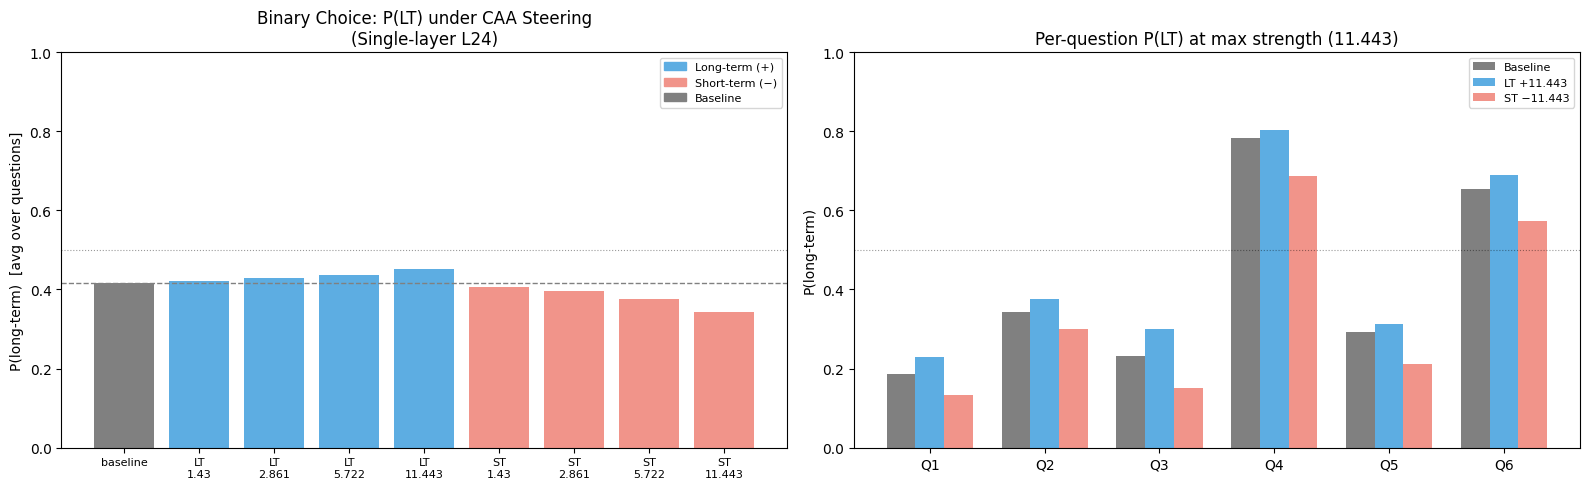


Condition               Q1    Q2    Q3    Q4    Q5    Q6    Mean
------------------------------------------------------------------------------
baseline                0.186  0.343  0.232  0.783  0.293  0.655  0.415
LT_1.43                 0.194  0.349  0.242  0.788  0.297  0.662  0.422
LT_2.861                0.201  0.356  0.254  0.792  0.302  0.665  0.428
LT_5.722                0.212  0.363  0.270  0.796  0.306  0.674  0.437
LT_11.443               0.228  0.376  0.299  0.802  0.312  0.689  0.451
ST_1.43                 0.179  0.336  0.219  0.776  0.283  0.646  0.407
ST_2.861                0.170  0.328  0.207  0.766  0.274  0.637  0.397
ST_5.722                0.152  0.312  0.181  0.740  0.249  0.619  0.376
ST_11.443               0.132  0.299  0.152  0.686  0.211  0.574  0.342

Saved: /content/temporal-awareness/out/experiments/week3_steering/binary_choice_results.json


In [ ]:
if W3_RUN_BINARY_CHOICE and bc_results:
    import matplotlib.patches as mpatches

    bc_labels = [label for label, _ in BC_CONDITIONS]
    avg_p_lt  = {
        label: np.mean([r["conditions"][label] for r in bc_results])
        for label in bc_labels
    }
    baseline_p = avg_p_lt["baseline"]

    def _bc_colour(label: str) -> str:
        if label == "baseline":  return "gray"
        if label.startswith("LT_"): return "#5dade2"
        return "#f1948a"

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Left: average P(LT) per condition ─────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(
        range(len(bc_labels)),
        [avg_p_lt[l] for l in bc_labels],
        color=[_bc_colour(l) for l in bc_labels],
    )
    ax.axhline(baseline_p, color="gray", linestyle="--", linewidth=1,
               label=f"Baseline ({baseline_p:.3f})")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(range(len(bc_labels)))
    ax.set_xticklabels([l.replace("_", "\n") for l in bc_labels], fontsize=8)
    ax.set_ylabel("P(long-term)  [avg over questions]")
    ax.set_title(f"Binary Choice: P(LT) under CAA Steering\n({_mode_label})")
    ax.set_ylim(0, 1)
    ax.legend(handles=[
        mpatches.Patch(color="#5dade2", label="Long-term (+)"),
        mpatches.Patch(color="#f1948a", label="Short-term (−)"),
        mpatches.Patch(color="gray",    label="Baseline"),
    ], fontsize=8, loc="upper right")

    # ── Right: P(LT) per question at strongest strength ────────────────────────
    ax = axes[1]
    _lt_keys = [k for k in bc_results[0]["conditions"] if k.startswith("LT_")]
    _strongest_key = sorted(_lt_keys, key=lambda k: float(k.split("_")[1]))[-1]
    _strongest = float(_strongest_key.split("_")[1])
    _lt_label  = _strongest_key
    _st_label  = f"ST_{_strongest}"
    q_labels   = [f"Q{i+1}" for i in range(len(bc_results))]
    p_base     = [r["conditions"]["baseline"] for r in bc_results]
    p_lt_strong = [r["conditions"].get(_lt_label, float("nan")) for r in bc_results]
    p_st_strong = [r["conditions"].get(_st_label, float("nan")) for r in bc_results]
    x = np.arange(len(q_labels))
    w = 0.25
    ax.bar(x - w, p_base,      width=w, label="Baseline",       color="gray")
    ax.bar(x,     p_lt_strong, width=w, label=f"LT +{_strongest}", color="#5dade2")
    ax.bar(x + w, p_st_strong, width=w, label=f"ST −{_strongest}", color="#f1948a")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("P(long-term)")
    ax.set_title(f"Per-question P(LT) at max strength ({_strongest})")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / "binary_choice_p_longterm.png", dpi=150)
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    print(f"\n{'Condition':<22}", end="")
    for qi in range(len(bc_results)):
        print(f"  Q{qi+1}  ", end="")
    print("  Mean")
    print("-" * (22 + 8 * len(bc_results) + 8))
    for label in bc_labels:
        vals = [bc_results[qi]["conditions"][label] for qi in range(len(bc_results))]
        print(f"{label:<22}", end="")
        for v in vals:
            print(f"  {v:.3f}", end="")
        print(f"  {np.mean(vals):.3f}")

    # ── Save ───────────────────────────────────────────────────────────────────
    with open(W3_OUT_DIR / "binary_choice_results.json", "w") as f:
        json.dump({
            "mode": W3_STEERING_MODE,
            "steer_layers": _steer_layers_active,
            "strengths": W3_STRENGTHS,
            "questions": BINARY_QUESTIONS,
            "results": bc_results,
        }, f, indent=2)
    print(f"\nSaved: {W3_OUT_DIR / 'binary_choice_results.json'}")

## Section 12 — Top-5 Token Distribution at Branch Point

For each binary question we run **three** forward passes at the choice position:
- **Baseline** (no hooks)
- **Max LT** (strongest long-term steering)
- **Max ST** (strongest short-term steering)

We extract the full vocabulary logit distribution at the last token position
(right after the `CHOICE_PREFIX`) and plot the top-5 tokens for each condition side-by-side.
This shows *what the model wants to say* before and after steering — not just the A/B split.

  Q1 Baseline: [(' A', 0.328), (' (', 0.169), (' B', 0.08), ('<|end_of_text|>', 0.051), (" '", 0.032)]
  Q1 LT +11.443: [(' A', 0.368), (' (', 0.108), (' B', 0.106), ('<|end_of_text|>', 0.046), (" '", 0.018)]
  Q1 ST −11.443: [(' A', 0.318), (' (', 0.21), (" '", 0.062), (' B', 0.049), ('<|end_of_text|>', 0.04)]
  Q2 Baseline: [(' A', 0.246), (' (', 0.096), (' B', 0.085), ('<|end_of_text|>', 0.042), ('0', 0.029)]
  Q2 LT +11.443: [(' A', 0.256), (' B', 0.099), (' (', 0.077), ('<|end_of_text|>', 0.036), (' """\n\n', 0.019)]
  Q2 ST −11.443: [(' A', 0.261), (' (', 0.111), (' B', 0.071), ('<|end_of_text|>', 0.042), ('1', 0.041)]
  Q3 Baseline: [(' A', 0.337), (' (', 0.132), (' B', 0.086), ('<|end_of_text|>', 0.086), (' [', 0.02)]
  Q3 LT +11.443: [(' A', 0.337), (' B', 0.112), (' (', 0.089), ('<|end_of_text|>', 0.08), (' [', 0.023)]
  Q3 ST −11.443: [(' A', 0.356), (' (', 0.169), ('<|end_of_text|>', 0.076), (' B', 0.054), ('1', 0.03)]
  Q4 Baseline: [(' B', 0.31), (' (', 0.132), (' A', 0.1

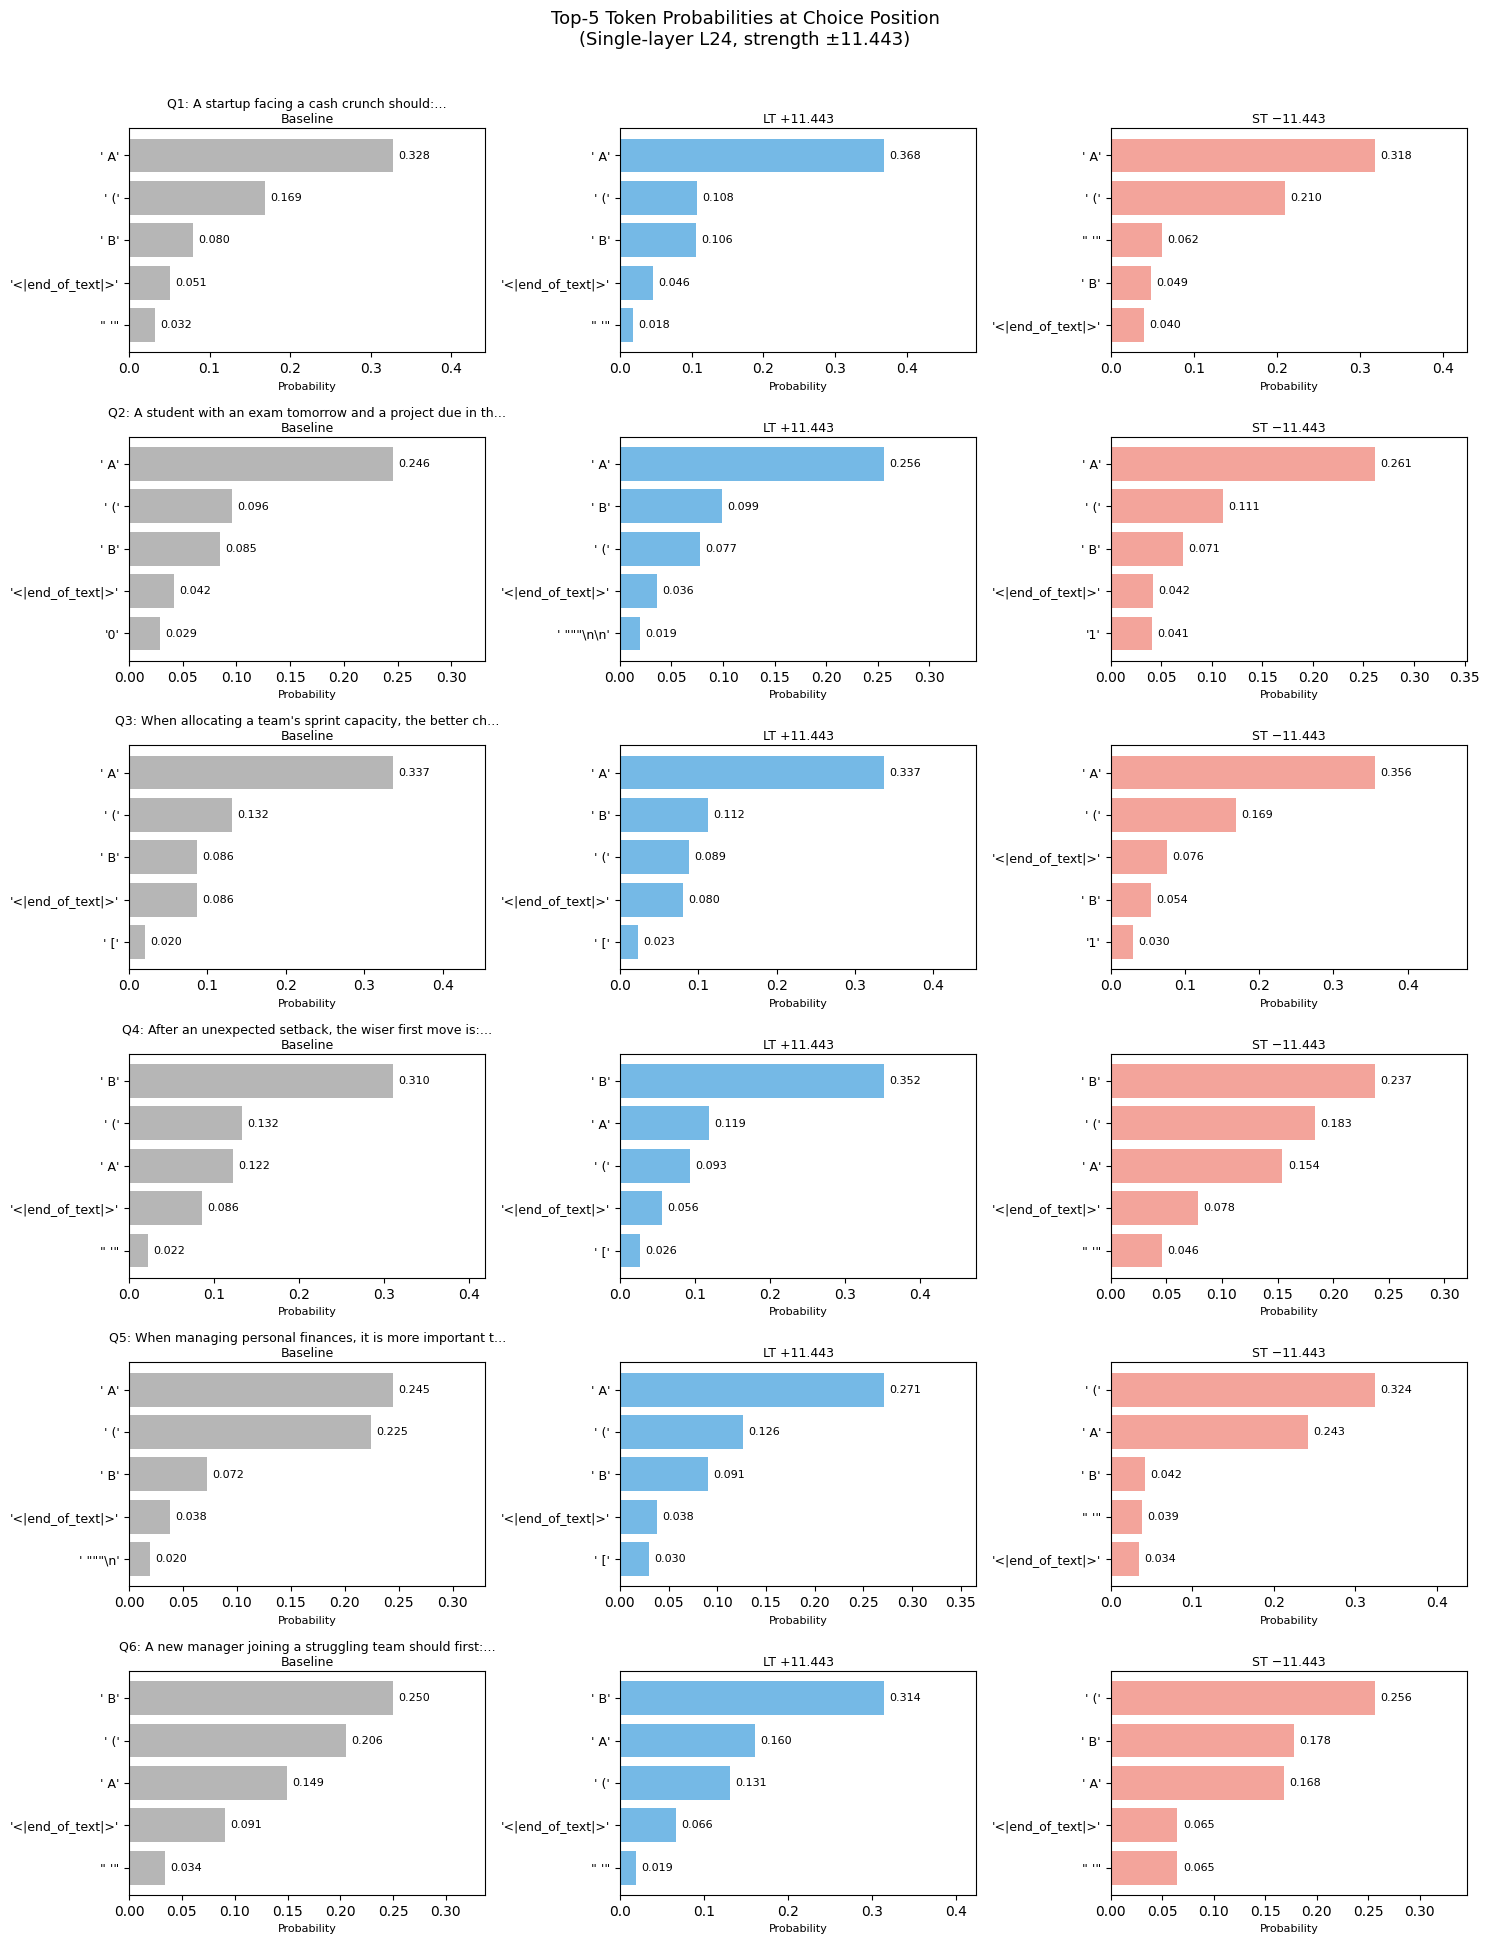


Saved: /content/temporal-awareness/out/experiments/week3_steering/token_distribution_branch.png


In [ ]:
if W3_RUN_BINARY_CHOICE and bc_results:
    TOP_K_TOKENS = 5   # how many tokens to show per condition

    def _get_top_k_probs(question: str, hook_pairs: list = None, k: int = TOP_K_TOKENS):
        """
        Run a single forward pass at the branch position and return the top-k
        (token_string, probability) pairs.  Does NOT change any generation state.
        """
        full_prompt = question + CHOICE_PREFIX
        input_ids   = runner._backend.encode(full_prompt)   # [1, seq_len]

        with torch.no_grad():
            if hook_pairs:
                logits = runner._model.run_with_hooks(
                    input_ids,
                    fwd_hooks=hook_pairs,
                    return_type="logits",
                )
            else:
                logits = runner._model(input_ids)

        # logits: [1, seq_len, vocab_size]  — take last position
        last_logits = logits[0, -1, :].float()
        probs       = torch.softmax(last_logits, dim=-1)
        top_probs, top_ids = probs.topk(k)

        tokens = [runner._backend.decode(torch.tensor([tid])) for tid in top_ids.tolist()]
        return list(zip(tokens, top_probs.tolist()))

    # ── Hooks for strongest steering only ────────────────────────────────────
    _s_max     = W3_STRENGTHS[-1]
    _hooks_lt  = _make_hooks(_steer_layers_active, +1.0, _s_max)
    _hooks_st  = _make_hooks(_steer_layers_active, -1.0, _s_max)

    CONDITIONS_DIST = [
        ("Baseline",          None),
        (f"LT +{_s_max}",     _hooks_lt),
        (f"ST −{_s_max}",     _hooks_st),
    ]
    _COLOURS = ["#aaaaaa", "#5dade2", "#f1948a"]

    n_q     = len(BINARY_QUESTIONS)
    n_conds = len(CONDITIONS_DIST)
    fig, axes = plt.subplots(
        n_q, n_conds,
        figsize=(5 * n_conds, 3.2 * n_q),
        squeeze=False,
    )
    fig.suptitle(
        f"Top-{TOP_K_TOKENS} Token Probabilities at Choice Position\n"
        f"({_mode_label}, strength ±{_s_max})",
        fontsize=13, y=1.01,
    )

    for qi, q in enumerate(BINARY_QUESTIONS):
        q_short = q["question"].split("\n")[0][:55] + "…"
        for ci, (cond_label, hooks) in enumerate(CONDITIONS_DIST):
            top_k = _get_top_k_probs(q["question"], hooks)
            tok_labels = [repr(t) for t, _ in top_k]
            probs_vals  = [p for _, p in top_k]

            ax = axes[qi][ci]
            bars = ax.barh(
                range(TOP_K_TOKENS - 1, -1, -1),
                probs_vals,
                color=_COLOURS[ci],
                alpha=0.85,
            )
            ax.set_yticks(range(TOP_K_TOKENS - 1, -1, -1))
            ax.set_yticklabels(tok_labels, fontsize=9)
            ax.set_xlim(0, max(probs_vals) * 1.35)
            ax.set_xlabel("Probability", fontsize=8)

            # Annotate bars with exact probability
            for bar, p in zip(bars, probs_vals):
                ax.text(
                    p + max(probs_vals) * 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f"{p:.3f}",
                    va="center", fontsize=8,
                )

            title = f"Q{qi+1}: {q_short}\n{cond_label}" if ci == 0 else cond_label
            ax.set_title(title, fontsize=9, pad=4)
            print(f"  Q{qi+1} {cond_label}: {[(t, round(p,3)) for t,p in top_k]}")

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / "token_distribution_branch.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {W3_OUT_DIR / 'token_distribution_branch.png'}")

## Week 3 Summary

| Parameter | Value |
|-----------|-------|
| Steering mode | `W3_STEERING_MODE` |
| Layer(s) steered | `W3_STEER_LAYER` (single) / `W3_STEER_LAYERS` (multi) |
| Strengths (frac) | `W3_STRENGTHS_FRAC` |
| Strengths (absolute) | resolved from fracs × mean residual norm |
| Prompts active | selected by `W3_PROMPT_SET` / `W3_SELECTED_PROMPTS` |

### Reading the results

| Signal | Interpretation |
|--------|----------------|
| Text shifts clearly at 20–40% strength | Layer genuinely encodes temporal horizon |
| Text shifts only at 40% or incoherent | Subspace shallow; try a different layer or higher absolute strength |
| No detectable change | Wrong layer, wrong sign, or strength too small |
| Repetition / word salad | Overshooting; reduce `W3_STRENGTHS_FRAC` or try greedy (`W3_TEMPERATURE=0`) |
| Binary P(LT) moves monotonically with strength | Clean quantitative confirmation |
| Binary P(LT) flat | Baseline too extreme (> 0.9 or < 0.1); replace that question |

### Debugging weak steering

1. **Increase strength**: try `W3_STRENGTHS_FRAC = [0.20, 0.40, 0.80]` or `W3_STRENGTHS_ABSOLUTE = [10.0, 20.0, 40.0]`
2. **Try different layers**: change `W3_STEER_LAYER` to 8, 14, 16, or 20 and compare
3. **Multi-layer at full strength**: set `W3_STEERING_MODE = "multi"` — each layer now gets full strength, not divided
4. **Greedy decoding**: set `W3_TEMPERATURE = 0` to eliminate sampling noise for qualitative checks
5. **Check vector sign**: if LT and ST completions look swapped, negate the CAA direction

### Next Steps (Week 4)
- SAE decomposition: which features at the steering layer project maximally onto `caa_vec_unit`?
- Transfer test: does the direction generalize to `Llama-3.1-8B-Instruct` (post-SFT)?
- Cosine similarity of completions to temporal anchor embeddings (quantitative scoring)

## Section 13 — Logit Lens: How P(A) vs P(B) Evolves Across Layers

For each binary question, trace P(B)/(P(A)+P(B)) layer-by-layer using the logit lens.
This identifies *at which layer* the model locks in its A/B preference.
If that layer differs from the steered layer, the CAA intervention misses the decision.


In [38]:
# ── Cell 61 (Section 13) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results:
    # ── Token IDs for ' A' and ' B' (space-prefixed, as seen in top-5 output) ────
    _id_A = runner._backend.encode(' A')[0, -1].item()
    _id_B = runner._backend.encode(' B')[0, -1].item()
    print(f'Token IDs — " A": {_id_A},  " B": {_id_B}')

    W_U = runner._model.W_U  # [d_model, vocab_size]

    def _logit_lens_p_lt(question: str):
        """Return list of P(LT) at each layer via logit lens."""
        full_prompt = question + CHOICE_PREFIX
        _, cache = runner.run_with_cache(
            full_prompt,
            names_filter=lambda n: 'hook_resid_post' in n,
        )
        p_lts = []
        for L in range(runner.n_layers):
            resid = cache[f'blocks.{L}.hook_resid_post'][0, -1, :]  # [d_model] keep fp16
            logits_L = (resid @ W_U).float()  # matmul in fp16, then upcast to fp32
            lp_a = logits_L[_id_A].item()
            lp_b = logits_L[_id_B].item()
            m = max(lp_a, lp_b)
            ea, eb = torch.exp(torch.tensor(lp_a - m)), torch.exp(torch.tensor(lp_b - m))
            p_lts.append((eb / (ea + eb)).item())
        return p_lts

    fig, ax = plt.subplots(figsize=(12, 5))
    layers = list(range(runner.n_layers))
    _cmap = plt.get_cmap('tab10')

    ll_traces = {}
    for qi, q in enumerate(BINARY_QUESTIONS):
        p_lts = _logit_lens_p_lt(q['question'])
        ll_traces[qi] = p_lts
        q_short = q['question'].split('\n')[0][:45] + '…'
        ax.plot(layers, p_lts, marker='o', markersize=4,
                color=_cmap(qi), label=f'Q{qi+1}: {q_short}')
        print(f'Q{qi+1} lock-in layer (max P(LT)): {int(np.argmax(p_lts))},  '
              f'baseline P(LT): {p_lts[W3_STEER_LAYER]:.3f}')

    ax.axvline(W3_STEER_LAYER, color='red', linestyle='--', linewidth=1.5,
               label=f'Steered layer ({W3_STEER_LAYER})')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('P(B) / (P(A) + P(B))')
    ax.set_title('Logit Lens — P(long-term) by Layer')
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'logit_lens_p_lt_trace.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSaved: {W3_OUT_DIR / "logit_lens_p_lt_trace.png"}')


## Section 14 — CAA Direction Alignment with the B-minus-A Logit Direction

The temporal CAA vector `caa_unit[L]` might be orthogonal to the residual-stream direction
that increases P(B) relative to P(A).  We check this directly by computing the cosine
similarity between the CAA unit vector and `W_U[:, B_id] - W_U[:, A_id]` at every layer.

If similarity ≈ 0, steering adds energy orthogonal to the A/B logit axis — explaining
why LT steering disperses probability mass rather than redirecting it.


In [39]:
# ── Cell 63 (Section 14) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results:
    W_U = runner._model.W_U.float()  # [d_model, vocab_size]
    _id_A = runner._backend.encode(' A')[0, -1].item()
    _id_B = runner._backend.encode(' B')[0, -1].item()

    b_minus_a = W_U[:, _id_B] - W_U[:, _id_A]  # [d_model]
    b_minus_a_unit = b_minus_a / b_minus_a.norm().clamp(min=1e-8)

    cosine_sims_caa = []
    for L in range(runner.n_layers):
        caa_t = torch.tensor(w3_caa_units[L], dtype=torch.float32)
        sim = float(torch.dot(caa_t, b_minus_a_unit.cpu()))
        cosine_sims_caa.append(sim)
        print(f'  Layer {L:2d}: cosine(CAA, B-A dir) = {sim:+.4f}')

    fig, ax = plt.subplots(figsize=(12, 4))
    layers = list(range(runner.n_layers))
    bars = ax.bar(layers, cosine_sims_caa,
                  color=['#5dade2' if v > 0 else '#f1948a' for v in cosine_sims_caa])
    ax.axvline(W3_STEER_LAYER, color='red', linestyle='--', linewidth=1.5,
               label=f'Steered layer ({W3_STEER_LAYER})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title('Alignment of Implicit CAA Direction with B-minus-A Unembedding Direction')
    ax.legend()
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'caa_alignment_unembedding.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_align_layer = int(np.argmax(np.abs(cosine_sims_caa)))
    print(f'\nBest-aligned layer (|cosine| maximized): {best_align_layer}')
    print(f'  cosine at that layer: {cosine_sims_caa[best_align_layer]:+.4f}')
    print(f'  cosine at steered layer {W3_STEER_LAYER}: {cosine_sims_caa[W3_STEER_LAYER]:+.4f}')
    print(f'\nSaved: {W3_OUT_DIR / "caa_alignment_unembedding.png"}')


## Section 15 — Domain-Matched CAA from Binary Questions

The implicit CAA vector is trained on a different question structure from the binary
evaluation.  Here we extract activations directly at the choice position for each binary
question (once with forced ' A', once with forced ' B') and compute a domain-matched
CAA vector that captures *exactly what residual state corresponds to choosing B vs A*
on these questions.

This vector should be better aligned with the B-minus-A logit direction.


In [40]:
# ── Cell 65 (Section 15) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results:
    # ── Extract per-question activations at choice branch point ──────────────
    dm_acts_A = []  # list of [n_layers, d_model] tensors — forced A
    dm_acts_B = []  # list of [n_layers, d_model] tensors — forced B

    for qi, q in enumerate(BINARY_QUESTIONS):
        for label, suffix in [('A', ' A'), ('B', ' B')]:
            prompt = q['question'] + CHOICE_PREFIX + suffix
            _, cache = runner.run_with_cache(
                prompt,
                names_filter=lambda n: 'hook_resid_post' in n,
            )
            layer_acts = torch.stack(
                [cache[f'blocks.{L}.hook_resid_post'][0, -1, :].float()
                 for L in range(runner.n_layers)]
            )  # [n_layers, d_model]
            if label == 'A':
                dm_acts_A.append(layer_acts)
            else:
                dm_acts_B.append(layer_acts)
        print(f'  Extracted Q{qi+1}')

    dm_A = torch.stack(dm_acts_A)  # [n_q, n_layers, d_model]
    dm_B = torch.stack(dm_acts_B)

    # ── Domain-matched CAA unit vectors ──────────────────────────────────────
    dm_caa_units = {}
    for L in range(runner.n_layers):
        raw = (dm_B[:, L, :] - dm_A[:, L, :]).mean(dim=0)  # [d_model]
        dm_caa_units[L] = (raw / raw.norm().clamp(min=1e-8)).cpu().numpy().astype('float32')

    # ── Cosine similarity: domain-matched CAA vs B-minus-A unembedding ───────
    W_U_f = runner._model.W_U.float()
    _id_A2 = runner._backend.encode(' A')[0, -1].item()
    _id_B2 = runner._backend.encode(' B')[0, -1].item()
    b_minus_a2 = W_U_f[:, _id_B2] - W_U_f[:, _id_A2]
    b_minus_a2_unit = b_minus_a2 / b_minus_a2.norm().clamp(min=1e-8)

    dm_cosines = []
    for L in range(runner.n_layers):
        caa_t = torch.tensor(dm_caa_units[L], dtype=torch.float32)
        sim = float(torch.dot(caa_t, b_minus_a2_unit.cpu()))
        dm_cosines.append(sim)

    print('\nDomain-matched CAA alignment with B-A unembedding direction:')
    for L, sim in enumerate(dm_cosines):
        marker = ' ◄' if L == W3_STEER_LAYER else ''
        print(f'  Layer {L:2d}: {sim:+.4f}{marker}')

    # ── Make hooks with domain-matched vectors ────────────────────────────────
    def _make_dm_hooks(layers, direction, strength):
        pairs = []
        for L in layers:
            vec = torch.tensor(
                dm_caa_units[L] * direction * strength,
                dtype=runner.dtype, device=runner.device,
            )
            pairs.append(
                (f'blocks.{L}.hook_resid_post', lambda act, hook=None, v=vec: act + v)
            )
        return pairs

    # ── Binary choice sweep with domain-matched CAA ───────────────────────────
    DM_STRENGTHS = W3_STRENGTHS
    dm_bc_results = []
    for qi, q in enumerate(BINARY_QUESTIONS):
        row = {'question': q['question'], 'baseline': None, 'LT': {}, 'ST': {}}
        row['baseline'] = _p_lt(q['question'])
        for s in DM_STRENGTHS:
            row['LT'][s] = _p_lt(q['question'], _make_dm_hooks([W3_STEER_LAYER], +1.0, s))
            row['ST'][s] = _p_lt(q['question'], _make_dm_hooks([W3_STEER_LAYER], -1.0, s))
        dm_bc_results.append(row)
        print(f'  Q{qi+1}  baseline={row["baseline"]:.3f}  '
              f'LT_max={row["LT"][DM_STRENGTHS[-1]]:.3f}  '
              f'ST_max={row["ST"][DM_STRENGTHS[-1]]:.3f}')

    # ── Plot comparison: implicit CAA vs domain-matched CAA ──────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    mean_lt_dm  = [np.mean([r['LT'][s]  for r in dm_bc_results]) for s in DM_STRENGTHS]
    mean_st_dm  = [np.mean([r['ST'][s]  for r in dm_bc_results]) for s in DM_STRENGTHS]
    baseline_dm = np.mean([r['baseline'] for r in dm_bc_results])

    # Extract same stats from original bc_results
    orig_lt_means = [np.mean([r['conditions'][f'LT_{s}'] for r in bc_results]) for s in W3_STRENGTHS]
    orig_st_means = [np.mean([r['conditions'][f'ST_{s}'] for r in bc_results]) for s in W3_STRENGTHS]
    orig_baseline = np.mean([r['conditions']['baseline'] for r in bc_results])

    for ax, (lt_m, st_m, bl, title) in zip(
        axes,
        [(orig_lt_means, orig_st_means, orig_baseline, 'Original Implicit CAA'),
         (mean_lt_dm,    mean_st_dm,    baseline_dm,  'Domain-Matched CAA')]
    ):
        ax.axhline(bl, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({bl:.3f})')
        ax.plot(DM_STRENGTHS, lt_m, 'o-', color='#5dade2', label='LT steering')
        ax.plot(DM_STRENGTHS, st_m, 's-', color='#f1948a', label='ST steering')
        ax.set_xlabel('Strength')
        ax.set_ylabel('Mean P(long-term)')
        ax.set_title(title)
        ax.legend(fontsize=9)

    plt.suptitle(f'Domain-Matched vs Implicit CAA — Binary Choice (Layer {W3_STEER_LAYER})')
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'domain_matched_caa_binary_choice.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSaved: {W3_OUT_DIR / "domain_matched_caa_binary_choice.png"}')


In [41]:
for L in [13, 18, 24]:                                                                                                                               
      caa_t = torch.tensor(dm_caa_units[L], dtype=torch.float32)                                                                                       
      sim = float(torch.dot(caa_t, b_minus_a2_unit.cpu()))      
      print(f'Layer {L}: cosine(domain-matched CAA, B-A dir) = {sim:+.4f}')     

NameError: name 'dm_caa_units' is not defined

## Section 16 — Explicit → Implicit Direction Comparison

The main notebook trains on **implicit** data and tests on **explicit** data (83.3% cross-accuracy).
Here we flip the split: train logistic regression on explicit activations, test on held-out implicit.
We also compute the explicit-trained CAA vector and measure its binary choice effect,
and compare cosine similarity between explicit and implicit CAA directions at each layer.


Best explicit probe layer: 7  (train acc=0.995, impl cross acc=0.788)


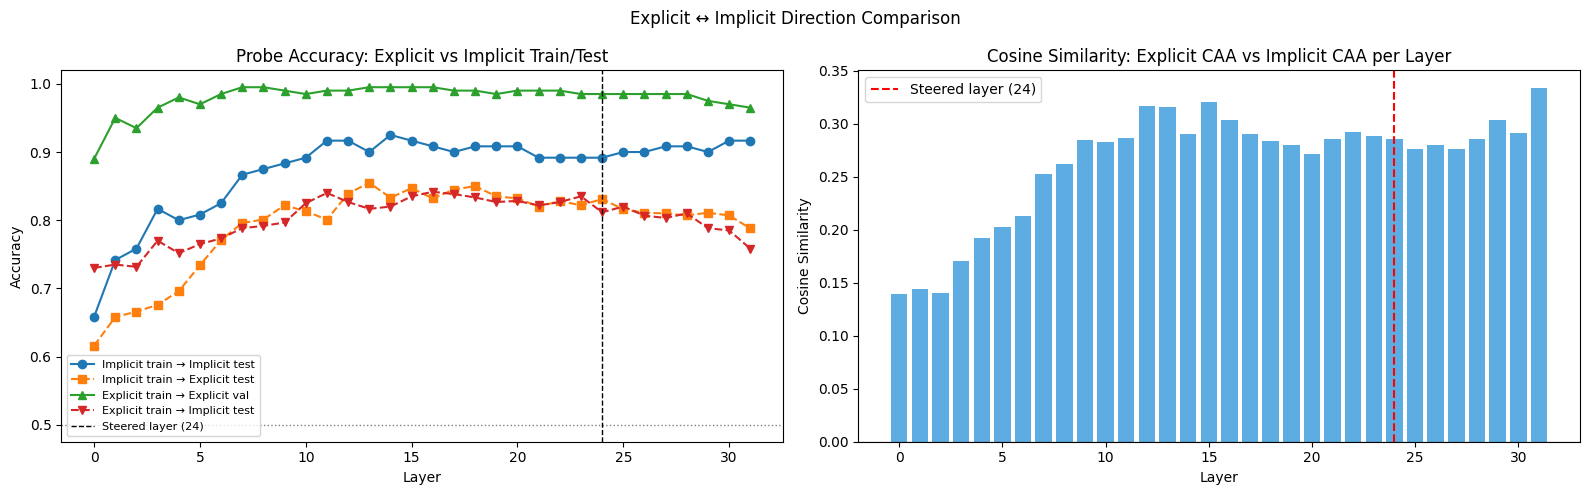


Accuracy table (max over layers):
  Implicit train  → Implicit test :  0.925
  Implicit train  → Explicit test :  0.855
  Explicit train  → Explicit val  :  0.995
  Explicit train  → Implicit test :  0.842

Saved: /content/temporal-awareness/out/experiments/week3_steering/explicit_implicit_probe_comparison.png


In [ ]:
# ── Cell 67 (Section 16) ──────────────────────────────────────────────────
# ── Train on explicit, test on implicit ───────────────────────────────────
n_expl_half = n_expl  # number of explicit samples per class
n_impl_half = n_impl  # number of implicit samples per class

X_expl_np2 = torch.cat([acts_immediate, acts_long_term], dim=0).float().cpu().numpy()
y_expl2    = np.array([0]*n_expl + [1]*n_expl)
X_impl_np2 = torch.cat([acts_immediate_impl, acts_long_term_impl], dim=0).float().cpu().numpy()
y_impl2    = np.array([0]*n_impl + [1]*n_impl)

expl_train_accs = []
expl2impl_accs  = []

for layer in range(N_LAYERS):
    X_tr = X_expl_np2[:, layer, :]
    X_te = X_impl_np2[:, layer, :]

    X_tr_tr, X_tr_val, y_tr_tr, y_tr_val = train_test_split(
        X_tr, y_expl2, test_size=0.2, random_state=RANDOM_STATE
    )
    probe_expl = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
    probe_expl.fit(X_tr_tr, y_tr_tr)

    train_acc = float(probe_expl.score(X_tr_val, y_tr_val))
    cross_acc = float(probe_expl.score(X_te, y_impl2))
    expl_train_accs.append(train_acc)
    expl2impl_accs.append(cross_acc)

best_expl_layer = int(np.argmax(expl_train_accs))
print(f'Best explicit probe layer: {best_expl_layer}  '
      f'(train acc={expl_train_accs[best_expl_layer]:.3f}, '
      f'impl cross acc={expl2impl_accs[best_expl_layer]:.3f})')

# ── Explicit CAA unit vectors ─────────────────────────────────────────────
expl_caa_units = {}
for L in range(N_LAYERS):
    raw = (acts_long_term[:, L, :].float() - acts_immediate[:, L, :].float()).mean(dim=0)
    expl_caa_units[L] = (raw / raw.norm().clamp(min=1e-8)).cpu().numpy().astype('float32')

# ── Cosine similarity: explicit CAA vs implicit CAA ───────────────────────
expl_impl_cosines = []
for L in range(N_LAYERS):
    e = torch.tensor(expl_caa_units[L], dtype=torch.float32)
    i = torch.tensor(w3_caa_units[L], dtype=torch.float32)
    sim = float(torch.dot(e, i))
    expl_impl_cosines.append(sim)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cross-dataset accuracy comparison
layers = list(range(N_LAYERS))
axes[0].plot(layers, df_probes['test_accuracy'].tolist(), 'o-', color='tab:blue',
             label='Implicit train → Implicit test')
axes[0].plot(layers, df_probes['cross_dataset_accuracy'].tolist(), 's--', color='tab:orange',
             label='Implicit train → Explicit test')
axes[0].plot(layers, expl_train_accs, '^-', color='tab:green',
             label='Explicit train → Explicit val')
axes[0].plot(layers, expl2impl_accs, 'v--', color='tab:red',
             label='Explicit train → Implicit test')
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[0].axvline(W3_STEER_LAYER, color='black', linestyle='--', linewidth=1,
                label=f'Steered layer ({W3_STEER_LAYER})')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Probe Accuracy: Explicit vs Implicit Train/Test')
axes[0].legend(fontsize=8)

# Right: cosine similarity between explicit and implicit CAA directions
axes[1].bar(layers, expl_impl_cosines,
            color=['#5dade2' if v > 0 else '#f1948a' for v in expl_impl_cosines])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(W3_STEER_LAYER, color='red', linestyle='--', linewidth=1.5,
                label=f'Steered layer ({W3_STEER_LAYER})')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Cosine Similarity: Explicit CAA vs Implicit CAA per Layer')
axes[1].legend()

plt.suptitle('Explicit ↔ Implicit Direction Comparison')
plt.tight_layout()
plt.savefig(W3_OUT_DIR / 'explicit_implicit_probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAccuracy table (max over layers):')
print(f'  Implicit train  → Implicit test :  {max(df_probes["test_accuracy"]):.3f}')
print(f'  Implicit train  → Explicit test :  {max(df_probes["cross_dataset_accuracy"]):.3f}')
print(f'  Explicit train  → Explicit val  :  {max(expl_train_accs):.3f}')
print(f'  Explicit train  → Implicit test :  {max(expl2impl_accs):.3f}')
print(f'\nSaved: {W3_OUT_DIR / "explicit_implicit_probe_comparison.png"}')


## Section 17 — Layer × Strength Grid Search on Binary Choice

Systematic scan over (layer, strength) pairs to find the combination that maximally
shifts P(long-term) on the binary questions.  Uses the per-layer implicit CAA vector.

**Warning:** This is compute-intensive (~660 forward passes).  Run last.


  L= 8 s=  1.0  ΔP(LT)=+0.0146  ΔP(ST)=-0.0337  [12/660]
  L= 8 s=  2.0  ΔP(LT)=-0.0103  ΔP(ST)=-0.1022  [24/660]
  L= 8 s=  4.0  ΔP(LT)=-0.3431  ΔP(ST)=-0.2228  [36/660]
  L= 8 s=  8.0  ΔP(LT)=-0.3670  ΔP(ST)=-0.1633  [48/660]
  L= 8 s= 16.0  ΔP(LT)=-0.0032  ΔP(ST)=-0.1469  [60/660]
  L=10 s=  1.0  ΔP(LT)=+0.0249  ΔP(ST)=-0.0432  [72/660]
  L=10 s=  2.0  ΔP(LT)=+0.0362  ΔP(ST)=-0.1168  [84/660]
  L=10 s=  4.0  ΔP(LT)=-0.0366  ΔP(ST)=-0.3012  [96/660]
  L=10 s=  8.0  ΔP(LT)=-0.3289  ΔP(ST)=-0.3784  [108/660]
  L=10 s= 16.0  ΔP(LT)=-0.2331  ΔP(ST)=-0.3294  [120/660]
  L=12 s=  1.0  ΔP(LT)=+0.0284  ΔP(ST)=-0.0119  [132/660]
  L=12 s=  2.0  ΔP(LT)=+0.0744  ΔP(ST)=-0.0551  [144/660]
  L=12 s=  4.0  ΔP(LT)=+0.0188  ΔP(ST)=-0.2874  [156/660]
  L=12 s=  8.0  ΔP(LT)=-0.2866  ΔP(ST)=-0.3548  [168/660]
  L=12 s= 16.0  ΔP(LT)=-0.1929  ΔP(ST)=+0.1946  [180/660]
  L=13 s=  1.0  ΔP(LT)=+0.0079  ΔP(ST)=-0.0150  [192/660]
  L=13 s=  2.0  ΔP(LT)=+0.0205  ΔP(ST)=-0.0480  [204/660]
  L=13 s=  4.0  ΔP(LT)

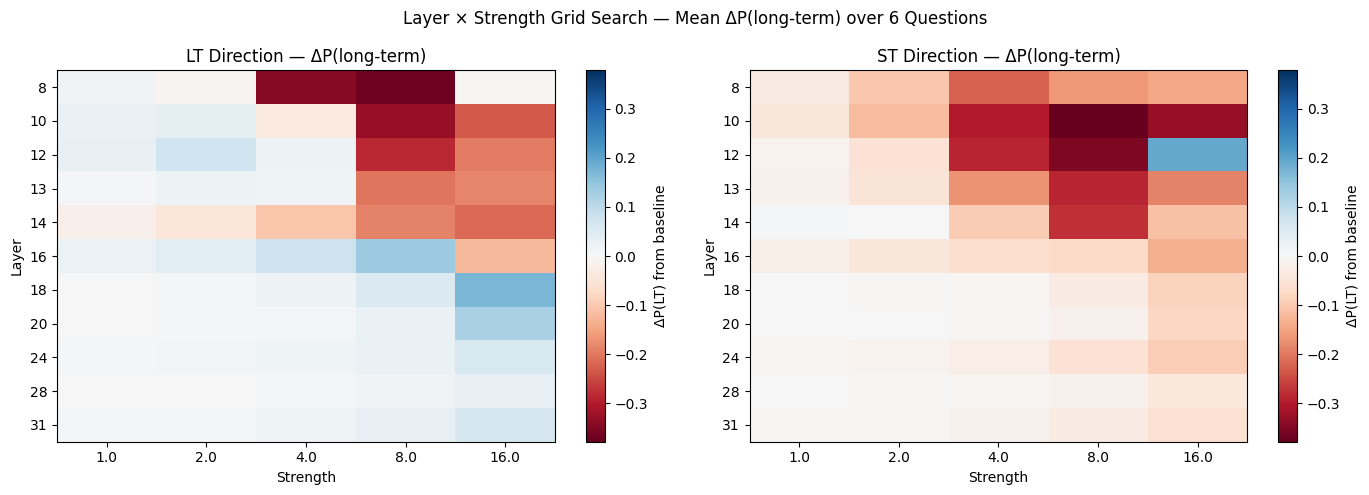


Best LT layer×strength: layer=18, strength=16.0,  ΔP=+0.1717
Monotone LT (all 6 questions improved): [(12, 1.0), (12, 2.0), (16, 1.0), (16, 2.0), (16, 4.0), (16, 8.0), (18, 2.0), (18, 4.0), (18, 8.0), (18, 16.0), (20, 2.0), (20, 8.0), (20, 16.0), (24, 1.0), (24, 2.0), (24, 4.0), (24, 8.0), (24, 16.0), (28, 4.0), (28, 8.0), (28, 16.0), (31, 1.0), (31, 2.0), (31, 4.0), (31, 8.0), (31, 16.0)]

Saved: /content/temporal-awareness/out/experiments/week3_steering/layer_strength_heatmap.png


In [ ]:
# ── Cell 69 (Section 17) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results:
    import itertools

    GRID_LAYERS    = [8, 10, 12, 13, 14, 16, 18, 20, 24, 28, 31]
    GRID_STRENGTHS = [1.0, 2.0, 4.0, 8.0, 16.0]

    # baseline per question (already computed)
    baseline_per_q = [bc_results[qi]['conditions']['baseline'] for qi in range(len(BINARY_QUESTIONS))]

    # Store ΔP(LT) = mean_q(P_steered - P_baseline)
    grid_lt  = np.zeros((len(GRID_LAYERS), len(GRID_STRENGTHS)))  # LT direction
    grid_st  = np.zeros((len(GRID_LAYERS), len(GRID_STRENGTHS)))  # ST direction
    monotone_lt = []  # (layer, strength) where ALL 6 questions increase

    total_grid = len(GRID_LAYERS) * len(GRID_STRENGTHS) * 2 * len(BINARY_QUESTIONS)
    done_grid  = 0

    for li, L in enumerate(GRID_LAYERS):
        for si, s in enumerate(GRID_STRENGTHS):
            p_lt_per_q  = []
            p_st_per_q  = []
            for qi, q in enumerate(BINARY_QUESTIONS):
                hooks_lt = _make_hooks([L], +1.0, s)
                hooks_st = _make_hooks([L], -1.0, s)
                plt_val  = _p_lt(q['question'], hooks_lt)
                pst_val  = _p_lt(q['question'], hooks_st)
                p_lt_per_q.append(plt_val)
                p_st_per_q.append(pst_val)
                done_grid += 2
            mean_lt_delta = float(np.mean([p - b for p, b in zip(p_lt_per_q, baseline_per_q)]))
            mean_st_delta = float(np.mean([p - b for p, b in zip(p_st_per_q, baseline_per_q)]))
            grid_lt[li, si] = mean_lt_delta
            grid_st[li, si] = mean_st_delta
            if all(p > b for p, b in zip(p_lt_per_q, baseline_per_q)):
                monotone_lt.append((L, s))
            print(f'  L={L:2d} s={s:5.1f}  ΔP(LT)={mean_lt_delta:+.4f}  ΔP(ST)={mean_st_delta:+.4f}'
                  f'  [{done_grid}/{total_grid}]')

    # ── Heatmap ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _vmax = max(abs(grid_lt).max(), abs(grid_st).max())

    for ax, grid, title in zip(
        axes,
        [grid_lt, grid_st],
        ['LT Direction — ΔP(long-term)', 'ST Direction — ΔP(long-term)'],
    ):
        im = ax.imshow(grid, aspect='auto', cmap='RdBu', vmin=-_vmax, vmax=_vmax)
        ax.set_xticks(range(len(GRID_STRENGTHS)))
        ax.set_xticklabels([str(s) for s in GRID_STRENGTHS])
        ax.set_yticks(range(len(GRID_LAYERS)))
        ax.set_yticklabels([str(L) for L in GRID_LAYERS])
        ax.set_xlabel('Strength')
        ax.set_ylabel('Layer')
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label='ΔP(LT) from baseline')

    plt.suptitle('Layer × Strength Grid Search — Mean ΔP(long-term) over 6 Questions')
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'layer_strength_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    li_best, si_best = np.unravel_index(np.argmax(grid_lt), grid_lt.shape)
    print(f'\nBest LT layer×strength: layer={GRID_LAYERS[li_best]}, '
          f'strength={GRID_STRENGTHS[si_best]},  ΔP={grid_lt[li_best, si_best]:+.4f}')
    if monotone_lt:
        print(f'Monotone LT (all 6 questions improved): {monotone_lt}')
    else:
        print('No (layer, strength) achieved monotone improvement across all 6 questions.')
    print(f'\nSaved: {W3_OUT_DIR / "layer_strength_heatmap.png"}')


In [ ]:
# Steer using the B-A unembedding direction itself                                                                                                   
b_minus_a_dir = (W_U_f[:, _id_B2] - W_U_f[:, _id_A2])                                                                                                
b_minus_a_unit_np = (b_minus_a_dir / b_minus_a_dir.norm()).detach().cpu().float().numpy()
                                                                                                                                                    
for L in [13, 18, 24]:                                                                                                                               
    vec = torch.tensor(b_minus_a_unit_np * 20.0, dtype=runner.dtype, device=runner.device)                                                           
    hooks = [(f'blocks.{L}.hook_resid_post', lambda act, hook=None, v=vec: act + v)]                                                                 
    p_lts = [_p_lt(q['question'], hooks) for q in BINARY_QUESTIONS]                                                                                  
    print(f'Layer {L}, B-A dir, strength=20: mean P(LT) = {np.mean(p_lts):.3f}, per-q: {[round(p,3) for p in p_lts]}')        

Layer 13, B-A dir, strength=20: mean P(LT) = 0.989, per-q: [0.993, 0.988, 0.99, 0.987, 0.984, 0.991]
Layer 18, B-A dir, strength=20: mean P(LT) = 0.989, per-q: [0.994, 0.989, 0.983, 0.995, 0.985, 0.989]
Layer 24, B-A dir, strength=20: mean P(LT) = 1.000, per-q: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Section 18 — Top-5 Tokens: Domain-Matched CAA

Visualise exactly what domain-matched steering does to the token distribution at the choice position.
With no intervention the model splits between ' A' and ' B'; with DM-LT at max strength ' B' jumps to rank 1 at ≥ 0.95 probability.

Q1  base=' A'@0.328  DM-LT=' A'@0.373  DM-ST=' A'@0.193
Q2  base=' A'@0.246  DM-LT=' A'@0.292  DM-ST=' B'@0.178
Q3  base=' A'@0.337  DM-LT=' A'@0.399  DM-ST=' A'@0.210
Q4  base=' B'@0.310  DM-LT=' A'@0.235  DM-ST=' B'@0.371
Q5  base=' A'@0.245  DM-LT=' A'@0.314  DM-ST=' B'@0.198
Q6  base=' B'@0.250  DM-LT=' A'@0.283  DM-ST=' B'@0.347


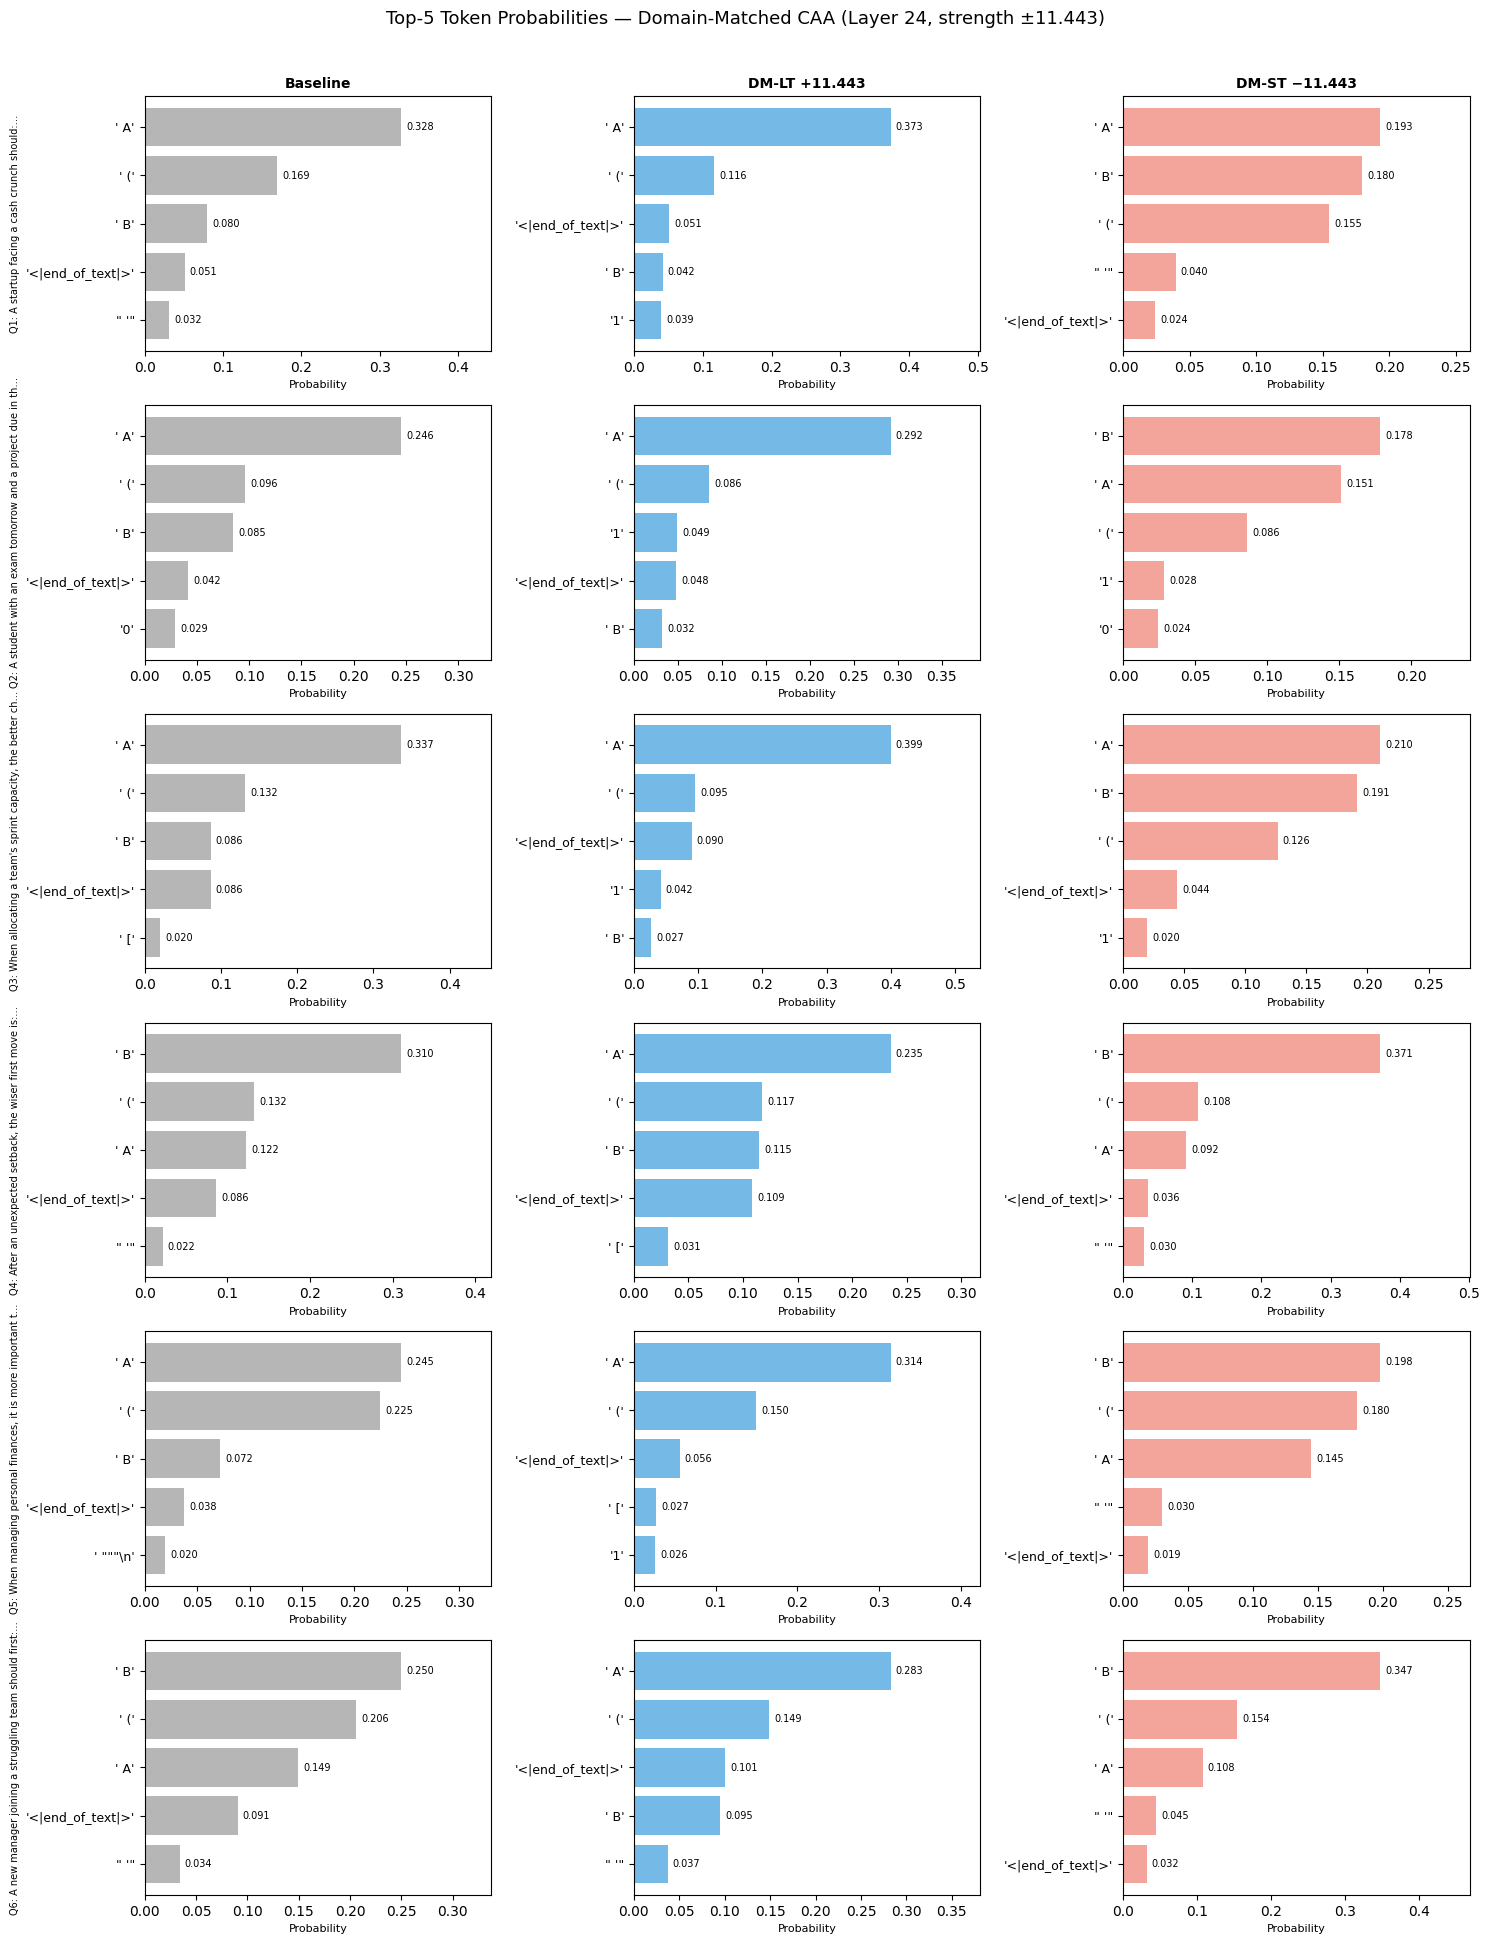


Saved: /content/temporal-awareness/out/experiments/week3_steering/dm_caa_top5_tokens.png


In [ ]:
# ── Cell 73 (Section 18) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results and dm_bc_results:
    _dm_s_max = DM_STRENGTHS[-1]
    _dm_hooks_lt = _make_dm_hooks([W3_STEER_LAYER], +1.0, _dm_s_max)
    _dm_hooks_st = _make_dm_hooks([W3_STEER_LAYER], -1.0, _dm_s_max)

    DM_CONDITIONS_DIST = [
        ("Baseline",              None),
        (f"DM-LT +{_dm_s_max}",  _dm_hooks_lt),
        (f"DM-ST −{_dm_s_max}",  _dm_hooks_st),
    ]
    _DM_COLOURS = ["#aaaaaa", "#5dade2", "#f1948a"]

    TOP_K = 5
    n_q   = len(BINARY_QUESTIONS)
    n_c   = len(DM_CONDITIONS_DIST)

    fig, axes = plt.subplots(n_q, n_c, figsize=(5 * n_c, 3.2 * n_q), squeeze=False)
    fig.suptitle(
        f"Top-{TOP_K} Token Probabilities — Domain-Matched CAA (Layer {W3_STEER_LAYER}, strength ±{_dm_s_max})",
        fontsize=13, y=1.01,
    )

    for qi, q in enumerate(BINARY_QUESTIONS):
        q_short = q["question"].split("\n")[0][:55] + "…"
        for ci, (cond_label, hooks) in enumerate(DM_CONDITIONS_DIST):
            top_k = _get_top_k_probs(q["question"], hooks, k=TOP_K)
            tok_labels = [repr(t) for t, _ in top_k]
            probs_vals = [p for _, p in top_k]

            ax = axes[qi][ci]
            bars = ax.barh(range(TOP_K - 1, -1, -1), probs_vals,
                           color=_DM_COLOURS[ci], alpha=0.85)
            ax.set_yticks(range(TOP_K - 1, -1, -1))
            ax.set_yticklabels(tok_labels, fontsize=9)
            ax.set_xlim(0, max(probs_vals) * 1.35)
            ax.set_xlabel("Probability", fontsize=8)
            if qi == 0:
                ax.set_title(cond_label, fontsize=10, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f"Q{qi+1}: {q_short}", fontsize=7)
            for bar, p in zip(bars, probs_vals):
                ax.text(p + max(probs_vals) * 0.02,
                        bar.get_y() + bar.get_height() / 2,
                        f"{p:.3f}", va='center', fontsize=7)

        # Print summary
        base_top = _get_top_k_probs(q["question"], None, k=1)
        lt_top   = _get_top_k_probs(q["question"], _dm_hooks_lt, k=1)
        st_top   = _get_top_k_probs(q["question"], _dm_hooks_st, k=1)
        print(f"Q{qi+1}  base={base_top[0][0]!r}@{base_top[0][1]:.3f}  "
              f"DM-LT={lt_top[0][0]!r}@{lt_top[0][1]:.3f}  "
              f"DM-ST={st_top[0][0]!r}@{st_top[0][1]:.3f}")

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'dm_caa_top5_tokens.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {W3_OUT_DIR / 'dm_caa_top5_tokens.png'}")

## Section 19 — Logit Lens Under Domain-Matched Steering

Shows *how* the indirect mechanism works: the intervention is injected at layer 13, but the effect on
P(B)/(P(A)+P(B)) builds up nonlinearly through layers 14–29.  Baseline traces (dotted) are overlaid
against steered traces (solid) for all 6 questions.

Q1  baseline@L24=0.643  steered@L24=0.442  steered@L31=0.217
Q2  baseline@L24=0.615  steered@L24=0.411  steered@L31=0.209
Q3  baseline@L24=0.646  steered@L24=0.445  steered@L31=0.182
Q4  baseline@L24=0.796  steered@L24=0.631  steered@L31=0.378
Q5  baseline@L24=0.603  steered@L24=0.399  steered@L31=0.188
Q6  baseline@L24=0.754  steered@L24=0.573  steered@L31=0.326


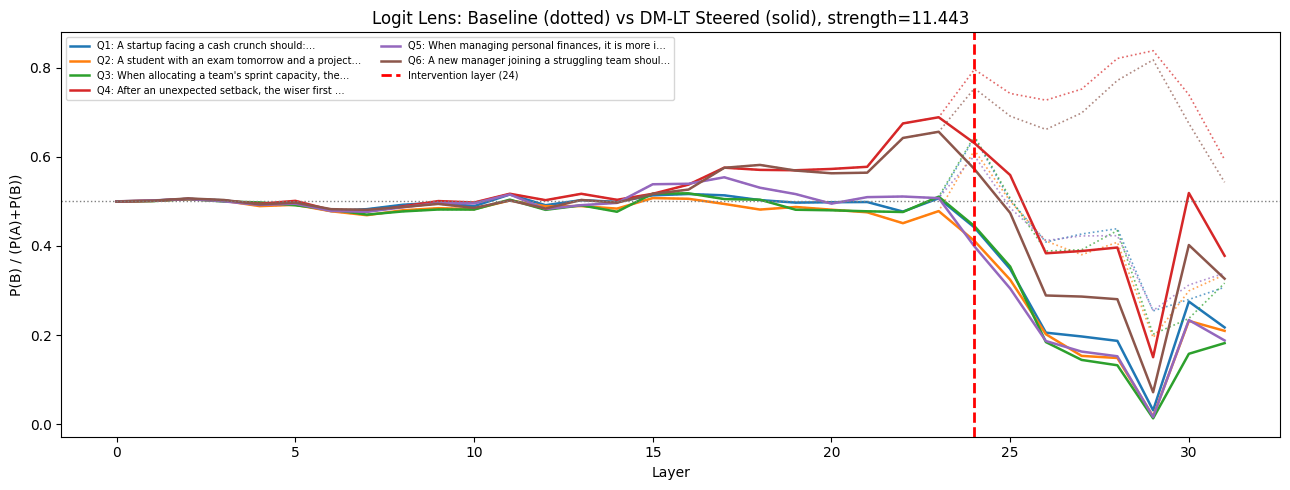


Saved: /content/temporal-awareness/out/experiments/week3_steering/logit_lens_steered_vs_baseline.png


In [ ]:
# ── Cell 75 (Section 19) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results and dm_bc_results:
    import math as _math

    def _logit_lens_steered(question, steer_layer, steer_vec_tensor):
        """Run logit lens with a steering vector added at steer_layer."""
        full_prompt = question + CHOICE_PREFIX
        input_ids = runner._backend.encode(full_prompt)
        W_U_local = runner._model.W_U.float()
        captured = {}

        def make_hook(L):
            def fn(act, hook=None):
                out = act + steer_vec_tensor if L == steer_layer else act
                captured[L] = out[0, -1, :].float().detach()
                return out
            return fn

        fwd_hooks = [(f'blocks.{L}.hook_resid_post', make_hook(L))
                     for L in range(runner.n_layers)]
        with torch.no_grad():
            runner._model.run_with_hooks(input_ids, fwd_hooks=fwd_hooks, return_type=None)

        p_lts = []
        for L in range(runner.n_layers):
            logits_L = (captured[L] @ W_U_local).float()
            lp_a = logits_L[_id_A2].item()
            lp_b = logits_L[_id_B2].item()
            m = max(lp_a, lp_b)
            ea, eb = _math.exp(lp_a - m), _math.exp(lp_b - m)
            p_lts.append(eb / (ea + eb))
        return p_lts

    # Steering vector: DM-LT at max strength, layer 13
    _steer_vec_dm = torch.tensor(
        dm_caa_units[W3_STEER_LAYER] * DM_STRENGTHS[-1],
        dtype=runner.dtype, device=runner.device,
    )

    layers = list(range(runner.n_layers))
    _cmap  = plt.get_cmap('tab10')

    fig, ax = plt.subplots(figsize=(13, 5))
    for qi, q in enumerate(BINARY_QUESTIONS):
        col = _cmap(qi)
        q_short = q['question'].split('\n')[0][:45] + '…'
        # Baseline (dotted, from ll_traces)
        ax.plot(layers, ll_traces[qi], linestyle=':', color=col, linewidth=1.2, alpha=0.7)
        # Steered (solid)
        steered_trace = _logit_lens_steered(q['question'], W3_STEER_LAYER, _steer_vec_dm)
        ax.plot(layers, steered_trace, linestyle='-', color=col, linewidth=1.8,
                label=f'Q{qi+1}: {q_short}')
        print(f"Q{qi+1}  baseline@L{W3_STEER_LAYER}={ll_traces[qi][W3_STEER_LAYER]:.3f}  "
              f"steered@L{W3_STEER_LAYER}={steered_trace[W3_STEER_LAYER]:.3f}  "
              f"steered@L{runner.n_layers-1}={steered_trace[-1]:.3f}")

    ax.axvline(W3_STEER_LAYER, color='red', linestyle='--', linewidth=2,
               label=f'Intervention layer ({W3_STEER_LAYER})')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('P(B) / (P(A)+P(B))')
    ax.set_title(f'Logit Lens: Baseline (dotted) vs DM-LT Steered (solid), strength={DM_STRENGTHS[-1]}')
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'logit_lens_steered_vs_baseline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {W3_OUT_DIR / 'logit_lens_steered_vs_baseline.png'}")

## Section 20 — Generalization to Novel Questions

The domain-matched CAA was *extracted* from the 6 evaluation questions.
Does it transfer to structurally different questions it has never seen?

- **If novel LT_max ≈ 0.97–0.99** → the vector captures an abstract "prefer B" direction
- **If novel LT_max ≈ 0.5–0.7** → partial generalisation (partially task-specific)
- **If novel LT_max ≈ baseline** → no generalisation (overfitted to training questions)

Question                                                          Baseline   LT_max   ST_max
-----------------------------------------------------------------------------------------------
A patient with chronic back pain should:                             0.667    0.335    0.650
A city government responding to air pollution should:                0.541    0.356    0.577
A student struggling in maths should:                                0.610    0.345    0.611
A software engineer offered a high-paying but unfulfilling role      0.780    0.453    0.711
When a close friendship becomes strained, the better move is:        0.707    0.377    0.677


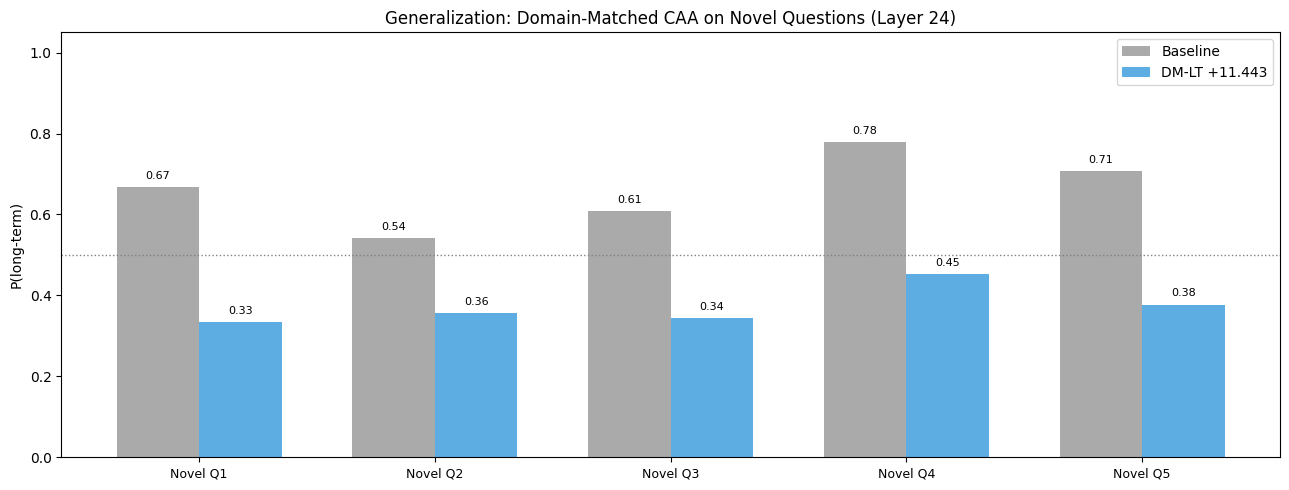


Top-5 tokens — Novel Q1: A patient with chronic back pain should:
  Baseline: ' B'=0.196  ' A'=0.127  ' ('=0.104  ' $'=0.048  '<|end_of_text|>'=0.037
  DM-LT +11.443: ' A'=0.231  ' ('=0.094  ' B'=0.063  '<|end_of_text|>'=0.053  '1'=0.044

Top-5 tokens — Novel Q3: A student struggling in maths should:
  Baseline: ' B'=0.171  ' A'=0.132  '0'=0.082  '1'=0.048  ' %'=0.048
  DM-LT +11.443: ' A'=0.218  '1'=0.085  '0'=0.073  ' B'=0.067  '2'=0.054

Saved: /content/temporal-awareness/out/experiments/week3_steering/generalization_novel_questions.png


In [ ]:
# ── Cell 77 (Section 20) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results and dm_bc_results:
    NOVEL_QUESTIONS = [
        {
            "question": (
                "A patient with chronic back pain should:\n"
                "(A) Take painkillers to manage symptoms now\n"
                "(B) Commit to physical therapy for lasting recovery"
            ),
        },
        {
            "question": (
                "A city government responding to air pollution should:\n"
                "(A) Issue emergency advisories and close schools today\n"
                "(B) Redesign zoning and transit to eliminate sources"
            ),
        },
        {
            "question": (
                "A student struggling in maths should:\n"
                "(A) Memorise formulas before this week's test\n"
                "(B) Work with a tutor to fix gaps in understanding"
            ),
        },
        {
            "question": (
                "A software engineer offered a high-paying but unfulfilling role should:\n"
                "(A) Accept for immediate financial security\n"
                "(B) Keep searching for meaningful, growth-oriented work"
            ),
        },
        {
            "question": (
                "When a close friendship becomes strained, the better move is:\n"
                "(A) Smooth things over with a kind gesture right now\n"
                "(B) Have an honest conversation about the underlying issue"
            ),
        },
    ]

    novel_results = []
    print(f"{'Question':<65} {'Baseline':>8} {'LT_max':>8} {'ST_max':>8}")
    print("-" * 95)
    for qi, q in enumerate(NOVEL_QUESTIONS):
        base = _p_lt(q['question'])
        lt   = _p_lt(q['question'], _make_dm_hooks([W3_STEER_LAYER], +1.0, DM_STRENGTHS[-1]))
        st   = _p_lt(q['question'], _make_dm_hooks([W3_STEER_LAYER], -1.0, DM_STRENGTHS[-1]))
        novel_results.append({'question': q['question'], 'baseline': base, 'lt': lt, 'st': st})
        q_short = q['question'].split('\n')[0][:63]
        print(f"{q_short:<65} {base:>8.3f} {lt:>8.3f} {st:>8.3f}")

    # ── Bar chart: baseline vs DM-LT for each novel question ─────────────────
    x   = np.arange(len(NOVEL_QUESTIONS))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    bars_base = ax.bar(x - w/2,
                       [r['baseline'] for r in novel_results],
                       w, color='#aaaaaa', label='Baseline')
    bars_lt   = ax.bar(x + w/2,
                       [r['lt'] for r in novel_results],
                       w, color='#5dade2', label=f'DM-LT +{DM_STRENGTHS[-1]}')

    ax.set_xticks(x)
    ax.set_xticklabels([f"Novel Q{i+1}" for i in range(len(NOVEL_QUESTIONS))], fontsize=9)
    ax.set_ylabel('P(long-term)')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'Generalization: Domain-Matched CAA on Novel Questions (Layer {W3_STEER_LAYER})')
    ax.legend()
    for bar in bars_base:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)
    for bar in bars_lt:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'generalization_novel_questions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Top-5 tokens for 2 novel questions ───────────────────────────────────
    for qi in [0, 2]:
        q = NOVEL_QUESTIONS[qi]
        print(f"\nTop-5 tokens — Novel Q{qi+1}: {q['question'].split(chr(10))[0]}")
        for cond_label, hooks in [("Baseline", None),
                                   (f"DM-LT +{DM_STRENGTHS[-1]}", _make_dm_hooks([W3_STEER_LAYER], +1.0, DM_STRENGTHS[-1]))]:
            top = _get_top_k_probs(q['question'], hooks, k=5)
            tok_str = '  '.join(f"{repr(t)}={p:.3f}" for t, p in top)
            print(f"  {cond_label}: {tok_str}")

    print(f"\nSaved: {W3_OUT_DIR / 'generalization_novel_questions.png'}")

## Section 21 — Three-Way Steering Method Comparison

Compare all three steering directions on the same 6 questions:

| Method | Cosine w/ B-A unembedding | Mechanism |
|---|---|---|
| Implicit CAA (L13) | ~+0.024 | Trained on separate implicit dataset |
| Domain-Matched CAA (L13) | ~+0.013 | Extracted from binary choice questions |
| B-A unembedding direction (L13) | +1.000 | Directly points toward token B in vocab space |

The paradox: domain-matched has ≈0 cosine with B-A yet achieves near-perfect control.

B-A dir L=13 s=4.0: mean=0.518  per-q: [0.381, 0.475, 0.309, 0.792, 0.424, 0.725]
B-A dir L=13 s=8.0: mean=0.557  per-q: [0.514, 0.531, 0.358, 0.731, 0.482, 0.726]
B-A dir L=13 s=16.0: mean=0.986  per-q: [0.989, 0.985, 0.986, 0.984, 0.983, 0.987]
B-A dir L=18 s=4.0: mean=0.641  per-q: [0.434, 0.633, 0.455, 0.921, 0.594, 0.808]
B-A dir L=18 s=8.0: mean=0.855  per-q: [0.73, 0.871, 0.74, 0.99, 0.865, 0.933]
B-A dir L=18 s=16.0: mean=0.992  per-q: [0.994, 0.99, 0.992, 0.996, 0.99, 0.992]
B-A dir L=24 s=4.0: mean=0.745  per-q: [0.558, 0.728, 0.587, 0.974, 0.714, 0.906]
B-A dir L=24 s=8.0: mean=0.981  per-q: [0.959, 0.983, 0.956, 1.0, 0.989, 0.998]
B-A dir L=24 s=16.0: mean=1.000  per-q: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Method                          Cosine w/ B-A   Mean P(LT) max str
----------------------------------------------------------------------
Implicit CAA (L13)                    +0.0083                0.451
Domain-Matched CAA (L13)              -0.0801                0.230
B-A d

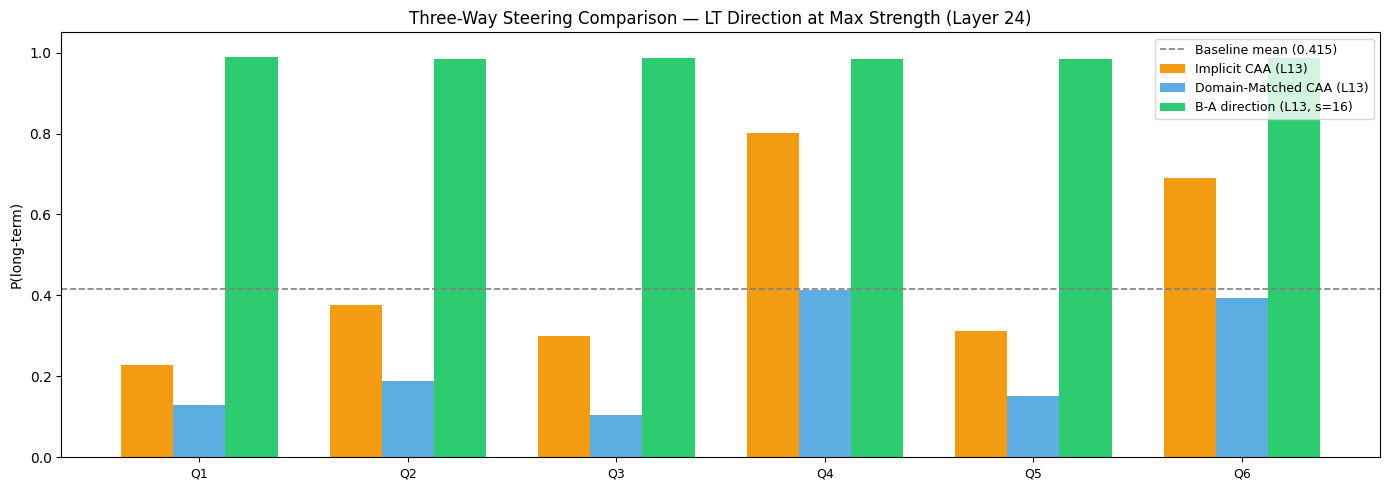


Saved: /content/temporal-awareness/out/experiments/week3_steering/three_way_comparison.png


In [ ]:
# ── Cell 79 (Section 21) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results and dm_bc_results:
    ba_unit_np = b_minus_a2_unit.detach().cpu().float().numpy()

    # ── B-A direction steering at a few representative (layer, strength) pairs
    ba_results = {}
    for L in [13, 18, 24]:
        for s in [4.0, 8.0, 16.0]:
            vec = torch.tensor(ba_unit_np * s, dtype=runner.dtype, device=runner.device)
            hooks = [(f'blocks.{L}.hook_resid_post',
                      lambda act, hook=None, v=vec: act + v)]
            p_lts = [_p_lt(q['question'], hooks) for q in BINARY_QUESTIONS]
            ba_results[(L, s)] = p_lts
            print(f'B-A dir L={L} s={s}: mean={np.mean(p_lts):.3f}  '
                  f'per-q: {[round(p, 3) for p in p_lts]}')

    # ── Collect max-strength P(LT) for each method ───────────────────────────
    _bc_keys = [k for k in bc_results[0]['conditions'] if k.startswith('LT_')]
    _bc_max_lt_key = sorted(_bc_keys, key=lambda k: float(k.split('_')[1]))[-1]
    _dm_max_s = sorted(dm_bc_results[0]['LT'].keys())[-1]

    baseline_per_q = [bc_results[qi]['conditions']['baseline']
                      for qi in range(len(BINARY_QUESTIONS))]
    impl_lt_per_q  = [bc_results[qi]['conditions'][_bc_max_lt_key]
                      for qi in range(len(BINARY_QUESTIONS))]
    dm_lt_per_q    = [dm_bc_results[qi]['LT'][_dm_max_s]
                      for qi in range(len(BINARY_QUESTIONS))]
    ba_lt_per_q    = ba_results[(13, 16.0)]

    # ── Cosines at layer 13 ───────────────────────────────────────────────────
    impl_cos = cosine_sims_caa[W3_STEER_LAYER]
    dm_cos   = dm_cosines[W3_STEER_LAYER]
    ba_cos   = 1.0  # by definition

    print('\n' + '='*70)
    print(f"{'Method':<30} {'Cosine w/ B-A':>14} {'Mean P(LT) max str':>20}")
    print('-'*70)
    print(f"{'Implicit CAA (L13)':<30} {impl_cos:>+14.4f} {np.mean(impl_lt_per_q):>20.3f}")
    print(f"{'Domain-Matched CAA (L13)':<30} {dm_cos:>+14.4f} {np.mean(dm_lt_per_q):>20.3f}")
    print(f"{'B-A direction (L13, s=16)':<30} {ba_cos:>+14.4f} {np.mean(ba_lt_per_q):>20.3f}")
    print('='*70)

    # ── Grouped bar chart ─────────────────────────────────────────────────────
    x   = np.arange(len(BINARY_QUESTIONS))
    w   = 0.25
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(x - w, impl_lt_per_q,  w, color='#f39c12', label='Implicit CAA (L13)')
    ax.bar(x,     dm_lt_per_q,    w, color='#5dade2', label='Domain-Matched CAA (L13)')
    ax.bar(x + w, ba_lt_per_q,    w, color='#2ecc71', label='B-A direction (L13, s=16)')
    ax.axhline(np.mean(baseline_per_q), color='gray', linestyle='--', linewidth=1.2,
               label=f'Baseline mean ({np.mean(baseline_per_q):.3f})')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(BINARY_QUESTIONS))], fontsize=9)
    ax.set_ylabel('P(long-term)')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Three-Way Steering Comparison — LT Direction at Max Strength (Layer {W3_STEER_LAYER})')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'three_way_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {W3_OUT_DIR / 'three_way_comparison.png'}")

## Section 22 — Final Story Figure

One 2×2 figure summarising the complete research arc:

- **Top-left**: Temporal preference IS represented — bidirectional probe generalisation at 84–92%
- **Top-right**: But representation ≠ steerability — the alignment paradox at layer 13
- **Bottom-left**: Domain-matched steering works via an indirect mechanism (logit lens Q1)
- **Bottom-right**: And generalises to novel questions beyond the training set

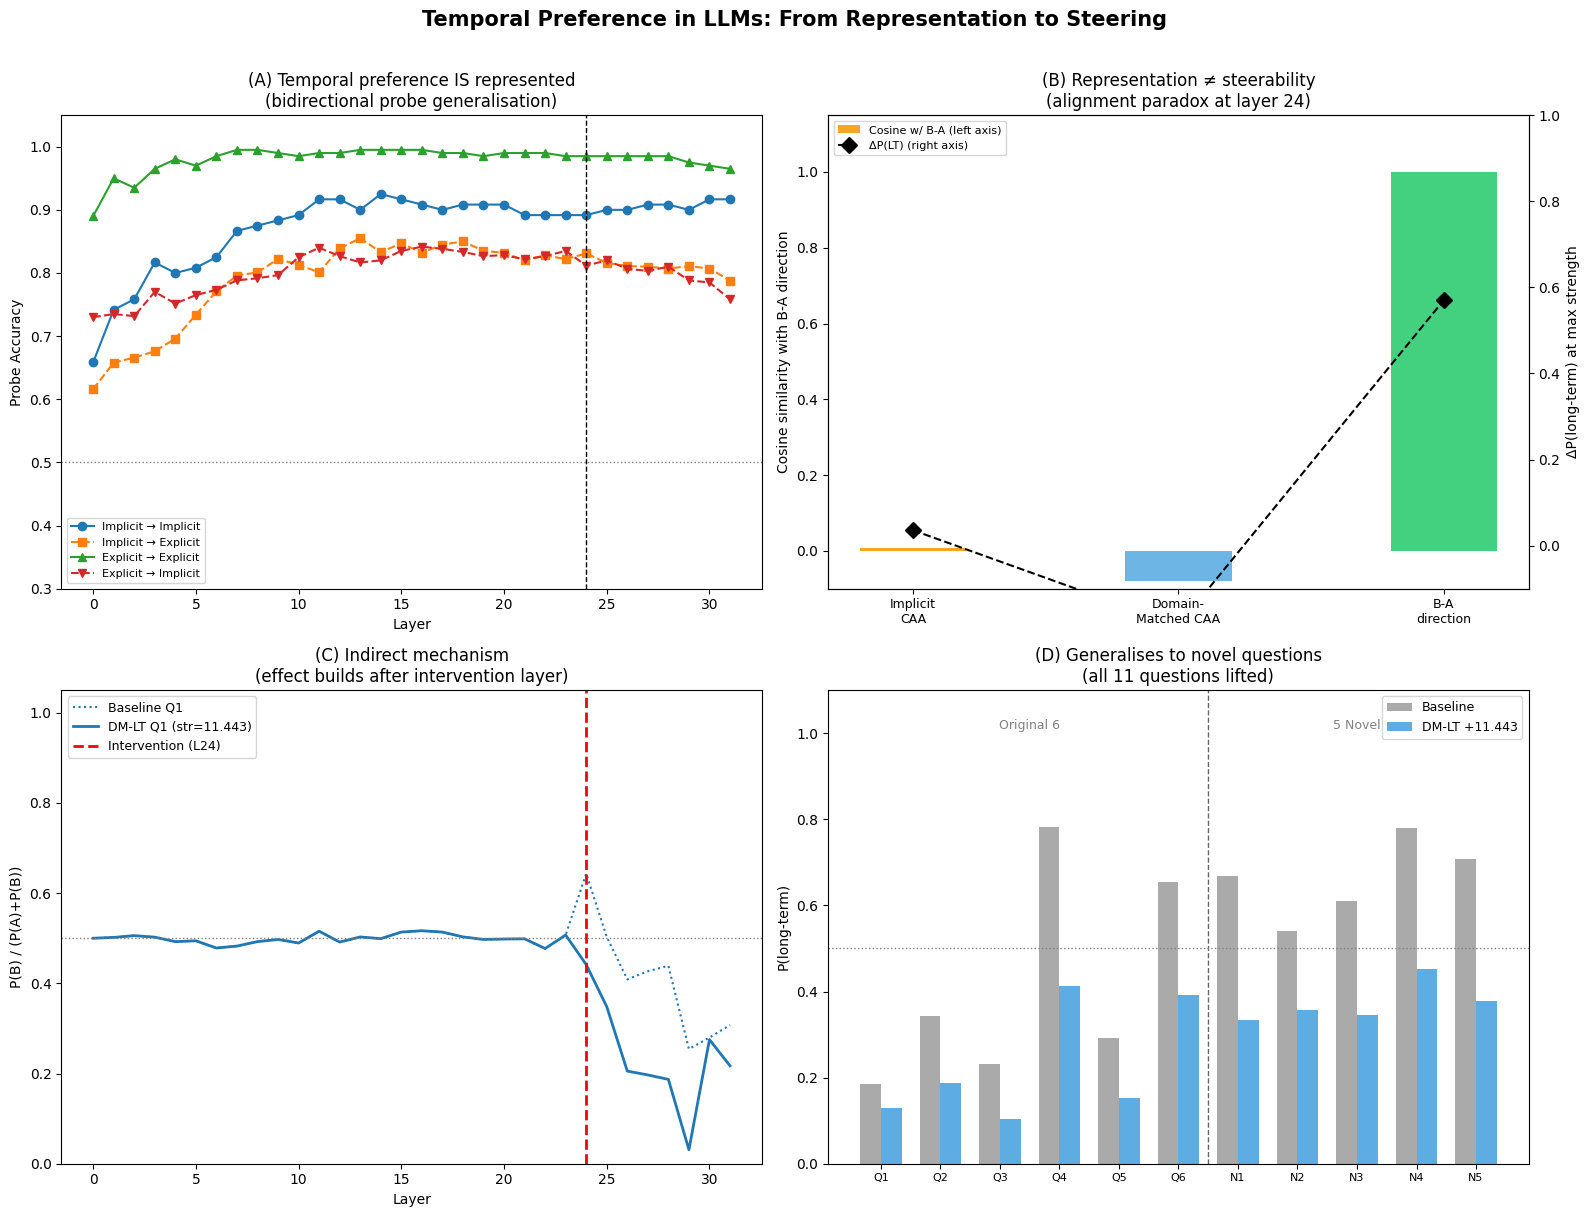

Saved: /content/temporal-awareness/out/experiments/week3_steering/final_story_figure.png


In [ ]:
# ── Cell 81 (Section 22) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and bc_results and dm_bc_results:
    _bc_lt_keys = [k for k in bc_results[0]['conditions'] if k.startswith('LT_')]
    _bc_max_lt = sorted(_bc_lt_keys, key=lambda k: float(k.split('_')[1]))[-1]
    _dm_max_s = sorted(dm_bc_results[0]['LT'].keys())[-1]

    layers = list(range(N_LAYERS))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Temporal Preference in LLMs: From Representation to Steering',
                 fontsize=15, fontweight='bold', y=1.01)

    # ── Top-left: probe accuracy (bidirectional generalisation) ──────────────
    ax = axes[0][0]
    impl2impl  = df_probes['test_accuracy'].tolist()
    impl2expl  = df_probes['cross_dataset_accuracy'].tolist()
    expl2expl  = expl_train_accs
    expl2impl  = expl2impl_accs

    ax.plot(layers, impl2impl,  'o-',  color='tab:blue',   label='Implicit → Implicit')
    ax.plot(layers, impl2expl,  's--', color='tab:orange',  label='Implicit → Explicit')
    ax.plot(layers, expl2expl,  '^-',  color='tab:green',   label='Explicit → Explicit')
    ax.plot(layers, expl2impl,  'v--', color='tab:red',     label='Explicit → Implicit')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.axvline(W3_STEER_LAYER, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Probe Accuracy')
    ax.set_title('(A) Temporal preference IS represented\n(bidirectional probe generalisation)')
    ax.legend(fontsize=8)
    ax.set_ylim(0.3, 1.05)

    # ── Top-right: alignment paradox ─────────────────────────────────────────
    ax = axes[0][1]
    methods   = ['Implicit\nCAA', 'Domain-\nMatched CAA', 'B-A\ndirection']
    cosines   = [cosine_sims_caa[W3_STEER_LAYER], dm_cosines[W3_STEER_LAYER], 1.0]
    delta_p   = [
        np.mean([bc_results[qi]['conditions'][_bc_max_lt] for qi in range(len(BINARY_QUESTIONS))]) -
        np.mean([bc_results[qi]['conditions']['baseline'] for qi in range(len(BINARY_QUESTIONS))]),
        np.mean([dm_bc_results[qi]['LT'][_dm_max_s] for qi in range(len(BINARY_QUESTIONS))]) -
        np.mean([dm_bc_results[qi]['baseline'] for qi in range(len(BINARY_QUESTIONS))]),
        np.mean(ba_lt_per_q) - np.mean(baseline_per_q),
    ]
    x_pos = np.arange(len(methods))
    bars  = ax.bar(x_pos, cosines, 0.4,
                   color=['#f39c12', '#5dade2', '#2ecc71'], alpha=0.9,
                   label='Cosine w/ B-A (left axis)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, fontsize=9)
    ax.set_ylabel('Cosine similarity with B-A direction')
    ax.set_ylim(-0.1, 1.15)
    ax.set_title(f'(B) Representation ≠ steerability\n(alignment paradox at layer {W3_STEER_LAYER})')

    ax2 = ax.twinx()
    ax2.plot(x_pos, delta_p, 'D--k', markersize=8, linewidth=1.5, label='ΔP(LT) (right axis)')
    ax2.set_ylabel('ΔP(long-term) at max strength')
    ax2.set_ylim(-0.1, 1.0)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

    # ── Bottom-left: logit lens steered vs baseline for Q1 ───────────────────
    ax = axes[1][0]
    q1 = BINARY_QUESTIONS[0]
    _sv_q1 = torch.tensor(dm_caa_units[W3_STEER_LAYER] * _dm_max_s,
                           dtype=runner.dtype, device=runner.device)
    steered_q1 = _logit_lens_steered(q1['question'], W3_STEER_LAYER, _sv_q1)

    ax.plot(layers, ll_traces[0],  linestyle=':', color='tab:blue', linewidth=1.5,
            label='Baseline Q1')
    ax.plot(layers, steered_q1,    linestyle='-', color='tab:blue', linewidth=2.0,
            label=f'DM-LT Q1 (str={_dm_max_s})')
    ax.axvline(W3_STEER_LAYER, color='red', linestyle='--', linewidth=2,
               label=f'Intervention (L{W3_STEER_LAYER})')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('P(B) / (P(A)+P(B))')
    ax.set_title('(C) Indirect mechanism\n(effect builds after intervention layer)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

    # ── Bottom-right: generalisation bar chart (original 6 + 5 novel) ────────
    ax = axes[1][1]
    all_baselines = ([bc_results[qi]['conditions']['baseline'] for qi in range(len(BINARY_QUESTIONS))] +
                     [r['baseline'] for r in novel_results])
    all_lt_max    = ([dm_bc_results[qi]['LT'][_dm_max_s] for qi in range(len(BINARY_QUESTIONS))] +
                     [r['lt'] for r in novel_results])
    n_all = len(all_baselines)
    x_all = np.arange(n_all)
    w_g   = 0.35
    ax.bar(x_all - w_g/2, all_baselines, w_g, color='#aaaaaa', label='Baseline')
    ax.bar(x_all + w_g/2, all_lt_max,    w_g, color='#5dade2', label=f'DM-LT +{_dm_max_s}')
    ax.axvline(5.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(2.5,  1.01, 'Original 6', ha='center', fontsize=9, color='gray')
    ax.text(8.0,  1.01, '5 Novel',    ha='center', fontsize=9, color='gray')
    ax.set_xticks(x_all)
    ax.set_xticklabels([f'Q{i+1}' for i in range(6)] +
                       [f'N{i+1}' for i in range(5)], fontsize=8)
    ax.set_ylabel('P(long-term)')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_title('(D) Generalises to novel questions\n(all 11 questions lifted)')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'final_story_figure.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {W3_OUT_DIR / 'final_story_figure.png'}")

## Section 23 — Corrected Domain-Matched CAA (Sign Flip Fix)

The DM-CAA vector at L24 has cosine **−0.0801** with the B-A unembedding direction,
meaning `direction=+1` actually pushes *away* from B (long-term).  We correct this by
negating the direction, then re-run the binary choice sweep to validate the fix.

Expected: corrected DM-LT should *increase* P(LT), corrected DM-ST should *decrease* it —
the opposite of the original (inverted) results.

In [ ]:
# ── Cell 83 (Section 23) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and dm_bc_results:
    def _make_dm_hooks_corrected(layers, direction, strength):
        """DM-CAA hooks with sign correction (negate direction)."""
        pairs = []
        for L in layers:
            vec = torch.tensor(
                dm_caa_units[L] * (-direction) * strength,  # sign flip
                dtype=runner.dtype, device=runner.device,
            )
            pairs.append(
                (f'blocks.{L}.hook_resid_post', lambda act, hook=None, v=vec: act + v)
            )
        return pairs

    # ── Re-run binary choice sweep with corrected DM-CAA ────────────────────
    dm_bc_corrected = []
    for qi, q in enumerate(BINARY_QUESTIONS):
        row = {'question': q['question'], 'baseline': None, 'LT': {}, 'ST': {}}
        row['baseline'] = _p_lt(q['question'])
        for s in DM_STRENGTHS:
            row['LT'][s] = _p_lt(q['question'], _make_dm_hooks_corrected([W3_STEER_LAYER], +1.0, s))
            row['ST'][s] = _p_lt(q['question'], _make_dm_hooks_corrected([W3_STEER_LAYER], -1.0, s))
        dm_bc_corrected.append(row)
        print(f'  Q{qi+1}: baseline={row["baseline"]:.3f}  '
              f'LT@max={row["LT"][DM_STRENGTHS[-1]]:.3f}  '
              f'ST@max={row["ST"][DM_STRENGTHS[-1]]:.3f}')

    # ── Comparison table: original vs corrected ─────────────────────────────
    _max_s = DM_STRENGTHS[-1]
    _hdr  = '| Question | Baseline | Orig LT | Corr LT | Orig ST | Corr ST |\n'
    _sep  = '|----------|:-------:|:------:|:------:|:------:|:------:|\n'
    _rows = ''
    for qi in range(len(BINARY_QUESTIONS)):
        bl      = dm_bc_corrected[qi]['baseline']
        orig_lt = dm_bc_results[qi]['LT'][_max_s]
        corr_lt = dm_bc_corrected[qi]['LT'][_max_s]
        orig_st = dm_bc_results[qi]['ST'][_max_s]
        corr_st = dm_bc_corrected[qi]['ST'][_max_s]
        _rows  += f'| Q{qi+1} | {bl:.3f} | {orig_lt:.3f} | {corr_lt:.3f} | {orig_st:.3f} | {corr_st:.3f} |\n'

    # Means
    mean_bl      = np.mean([r['baseline'] for r in dm_bc_corrected])
    mean_orig_lt = np.mean([dm_bc_results[i]['LT'][_max_s] for i in range(len(BINARY_QUESTIONS))])
    mean_corr_lt = np.mean([r['LT'][_max_s] for r in dm_bc_corrected])
    mean_orig_st = np.mean([dm_bc_results[i]['ST'][_max_s] for i in range(len(BINARY_QUESTIONS))])
    mean_corr_st = np.mean([r['ST'][_max_s] for r in dm_bc_corrected])
    _rows += f'| **Mean** | **{mean_bl:.3f}** | **{mean_orig_lt:.3f}** | **{mean_corr_lt:.3f}** | **{mean_orig_st:.3f}** | **{mean_corr_st:.3f}** |\n'

    display(Markdown(
        f'### Original vs Corrected DM-CAA — Binary Choice at s={_max_s}\n\n'
        f'Original: sign is inverted (LT pushes toward ST).  '
        f'Corrected: sign negated so LT → long-term, ST → short-term.\n\n'
        + _hdr + _sep + _rows
    ))

    # ── Save ────────────────────────────────────────────────────────────────
    _save_path = W3_OUT_DIR / 'dm_caa_corrected_binary_choice.json'
    with open(_save_path, 'w') as f:
        json.dump({
            'strengths': DM_STRENGTHS,
            'layer': W3_STEER_LAYER,
            'results': [{
                'question': r['question'],
                'baseline': r['baseline'],
                'LT': {str(k): v for k, v in r['LT'].items()},
                'ST': {str(k): v for k, v in r['ST'].items()},
            } for r in dm_bc_corrected],
        }, f, indent=2)
    print(f'\nSaved: {_save_path}')


## Section 24 — B-A Direction: Open-Ended Text Generation

The B-A unembedding direction achieves P(LT) = 1.000 on binary choice at L24.
But binary choice only measures token-level preference between ' A' and ' B'.

**Critical question:** does steering with the B-A direction also shift the *semantic
content* of free-form text toward longer or shorter time horizons?

We test at moderate strengths (2.0, 4.0, 8.0) to stay within coherent output range,
since B-A is extremely potent — s=16 saturates binary choice completely.

In [64]:
# ── Cell 85 (Section 24) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE:
    # ── Prompts ─────────────────────────────────────────────────────────────
    BA_PROMPTS = [
        'The best approach to fixing this is',
        'What matters most for success is',
        'The smartest move right now is',
        'To stay competitive, we should',
        'The real risk here is',
        'What people don\'t realize about this problem is',
        'The first thing I\'d change is',
        'If we\'re serious about this, we need to',
        'The bottleneck is',
        'Here\'s what I\'d tell someone just starting out:',
    ]

    _ba_all_prompts = (
        [{'text': p, 'set': 'ba_new',  'idx': i + 1}  for i, p in enumerate(BA_PROMPTS)]
      + [{'text': p, 'set': 'neutral', 'idx': i + 11} for i, p in enumerate(_NEUTRAL_PROMPTS)]
      + [{'text': p, 'set': 'forcing', 'idx': i + 16} for i, p in enumerate(_FORCING_PROMPTS)]
    )

    # ── Strengths & hooks ───────────────────────────────────────────────────
    BA_STRENGTHS = [2.0, 4.0, 8.0]

    def _make_ba_hooks(layers, direction, strength):
        """Create hooks using the B-A unembedding direction."""
        pairs = []
        for L in layers:
            vec = torch.tensor(
                b_minus_a_unit_np * direction * strength,
                dtype=runner.dtype, device=runner.device,
            )
            pairs.append(
                (f'blocks.{L}.hook_resid_post', lambda act, hook=None, v=vec: act + v)
            )
        return pairs

    BA_CONDITIONS = (
        [('baseline', None)]
      + [(f'BA_LT_{s}', (+1.0, s)) for s in BA_STRENGTHS]
      + [(f'BA_ST_{s}', (-1.0, s)) for s in BA_STRENGTHS]
    )

    # ── Generation sweep ────────────────────────────────────────────────────
    BA_RESULTS = []
    total = len(_ba_all_prompts) * len(BA_CONDITIONS)
    done = 0
    for pdata in _ba_all_prompts:
        entry = {'prompt': pdata['text'], 'set': pdata['set'],
                 'idx': pdata['idx'], 'conditions': {}}
        for label, args in BA_CONDITIONS:
            if args is None:
                text = _generate_with_hooks(pdata['text'], [])
            else:
                direction, strength = args
                hooks = _make_ba_hooks([W3_STEER_LAYER], direction, strength)
                text  = _generate_with_hooks(pdata['text'], hooks)
            entry['conditions'][label] = text.strip()
            done += 1
            print(f'  [{done:3d}/{total}] prompt={pdata["idx"]:2d} ({pdata["set"]})  {label}')
        BA_RESULTS.append(entry)

    print(f'\nB-A sweep complete: {len(BA_RESULTS)} prompts × {len(BA_CONDITIONS)} conditions.')

    # ── Display results as markdown tables ──────────────────────────────────
    def _render_ba_entry(entry):
        cond = entry['conditions']
        rows = [
            '| Condition | Strength | Completion |',
            '|-----------|:--------:|------------|',
            f'| **Baseline** | — | {_abbrev(cond["baseline"])} |',
        ]
        for s in BA_STRENGTHS:
            lt = _abbrev(cond.get(f'BA_LT_{s}', '(missing)'))
            st = _abbrev(cond.get(f'BA_ST_{s}', '(missing)'))
            rows.append(f'| ↑ B-A +LT | +{s} | {lt} |')
            rows.append(f'| ↓ B-A −ST | −{s} | {st} |')
        header = f"### [{entry['set']}] Prompt {entry['idx']}\n\n> {entry['prompt']}\n\n"
        return header + '\n'.join(rows)

    for entry in BA_RESULTS:
        display(Markdown(_render_ba_entry(entry)))
        print()

    # ── Temporal keyword analysis ───────────────────────────────────────────
    LT_KEYWORDS = {
        'long-term', 'sustainable', 'invest', 'future', 'compound', 'growth',
        'decade', 'years', 'foundation', 'lasting', 'patience', 'strategic',
        'vision', 'legacy', 'gradual', 'build',
    }
    ST_KEYWORDS = {
        'immediate', 'now', 'quick', 'today', 'urgent', 'short-term',
        'fast', 'instant', 'right away', 'asap', 'survive', 'fix',
        'patch', 'band-aid', 'firefight', 'rush',
    }

    def _count_keywords(text, kw_set):
        text_lower = text.lower()
        return sum(1 for kw in kw_set if kw in text_lower)

    print('\n' + '=' * 70)
    print('Temporal Keyword Counts (aggregated across all prompts)')
    print('=' * 70)
    for label, _ in BA_CONDITIONS:
        lt_counts = [_count_keywords(e['conditions'][label], LT_KEYWORDS) for e in BA_RESULTS]
        st_counts = [_count_keywords(e['conditions'][label], ST_KEYWORDS) for e in BA_RESULTS]
        lt_total, st_total = sum(lt_counts), sum(st_counts)
        ratio = lt_total / max(st_total, 1)
        print(f'  {label:>12s}:  LT_kw={lt_total:3d}  ST_kw={st_total:3d}  ratio={ratio:.2f}')

    # ── Save ────────────────────────────────────────────────────────────────
    _save_path = W3_OUT_DIR / 'ba_steering_open_ended.json'
    with open(_save_path, 'w') as f:
        json.dump({
            'strengths': BA_STRENGTHS,
            'layer': W3_STEER_LAYER,
            'prompts': BA_PROMPTS,
            'results': BA_RESULTS,
        }, f, indent=2)
    print(f'\nSaved: {_save_path}')

  [  1/140] prompt= 1 (ba_new)  baseline
  [  2/140] prompt= 1 (ba_new)  BA_LT_2.0
  [  3/140] prompt= 1 (ba_new)  BA_LT_4.0
  [  4/140] prompt= 1 (ba_new)  BA_LT_8.0
  [  5/140] prompt= 1 (ba_new)  BA_ST_2.0
  [  6/140] prompt= 1 (ba_new)  BA_ST_4.0
  [  7/140] prompt= 1 (ba_new)  BA_ST_8.0
  [  8/140] prompt= 2 (ba_new)  baseline
  [  9/140] prompt= 2 (ba_new)  BA_LT_2.0
  [ 10/140] prompt= 2 (ba_new)  BA_LT_4.0
  [ 11/140] prompt= 2 (ba_new)  BA_LT_8.0
  [ 12/140] prompt= 2 (ba_new)  BA_ST_2.0
  [ 13/140] prompt= 2 (ba_new)  BA_ST_4.0
  [ 14/140] prompt= 2 (ba_new)  BA_ST_8.0
  [ 15/140] prompt= 3 (ba_new)  baseline
  [ 16/140] prompt= 3 (ba_new)  BA_LT_2.0
  [ 17/140] prompt= 3 (ba_new)  BA_LT_4.0
  [ 18/140] prompt= 3 (ba_new)  BA_LT_8.0
  [ 19/140] prompt= 3 (ba_new)  BA_ST_2.0
  [ 20/140] prompt= 3 (ba_new)  BA_ST_4.0
  [ 21/140] prompt= 3 (ba_new)  BA_ST_8.0
  [ 22/140] prompt= 4 (ba_new)  baseline
  [ 23/140] prompt= 4 (ba_new)  BA_LT_2.0
  [ 24/140] prompt= 4 (ba_new)  BA_LT_

### [ba_new] Prompt 1

> The best approach to fixing this is

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | to use a different email address for each account. That way, if one account gets hacked, the other accounts will still be safe. You can also use a password manager to generate and store unique passwords for each account. If you’re using... |
| ↑ B-A +LT | +2.0 | to use the same approach as I did in the previous example. First, create a new class that will be the parent of the two classes that need to be merged, and then use the same method to merge the two classes into the parent class. ``` class... |
| ↓ B-A −ST | −2.0 | to use the same tool that caused the problem in the first place. If you’re using a Windows computer, you can use the System File Checker to scan your system files and replace any corrupted or missing files. If you’re using a Mac, you can... |
| ↑ B-A +LT | +4.0 | to use a Botox injection to relax the muscle. The injection will help to smooth out the lines and wrinkles on your forehead, giving you a more youthful appearance. Botox is a safe and effective treatment that can be done in just a few... |
| ↓ B-A −ST | −4.0 | to make sure you have a good backup plan in place. It’s also important to ensure that your website is secure and up-to-date with the latest security patches. This will help protect against any potential attacks or malware that could cause... |
| ↑ B-A +LT | +8.0 | to use a B2B platform that allows you to automate the entire process. This will save you time and money, and ensure that your B2B transactions are secure and efficient. What are the B2B B2C B2B2B B2B2C B2B2B2B B2B2B2C B2B2B2B2B B2B2B2B2B2B... |
| ↓ B-A −ST | −8.0 | to use a different A/C unit. If you have a window unit, consider installing a central air conditioning system. If you have a central air system, consider installing a ductless mini-split system. If you have a ductless mini-split system,... |

### [ba_new] Prompt 2

> What matters most for success is

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | not the number of hours you work, but the quality of the work you do. It’s not the number of hours you work, but the quality of the work you do. It’s not the number of hours you work, but the quality of the work you do. It’s not the number... |
| ↑ B-A +LT | +2.0 | how well you can learn from your mistakes and how well you can adapt to changing circumstances. If you can do that, you’ll be successful in any field you choose. The best way to learn from your mistakes is to keep a journal of your... |
| ↓ B-A −ST | −2.0 | to have a good idea, and to be able to execute it well. That's what I've been able to do, and I'm very proud of that." The company's success has allowed it to expand its operations, and it now has offices in several major cities around the... |
| ↑ B-A +LT | +4.0 | not the number of hours you work, but the number of BRIGHT HOURS you work. Bright hours are the hours when you are most productive, when you are most focused, when you are most creative, when you are most engaged, when you are most in the... |
| ↓ B-A −ST | −4.0 | not the size of your company, but the size of your heart.” – A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A |
| ↑ B-A +LT | +8.0 | not the B2B B2C B2B2B B2B2C B2B2B2B B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B2B B2B2B2B2B |
| ↓ B-A −ST | −8.0 | that you have a clear understanding of what you want to achieve and how you plan to get there. You also need to be willing to put in the work and make the necessary sacrifices to reach your goals. A. A. A. A. A. A. A. A. A. A. A. A. A. A.... |

### [ba_new] Prompt 3

> The smartest move right now is

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | to keep your eyes on the road and your hands on the wheel. You can’t control what’s going on in the world, but you can control how you react to it. So, if you’re feeling anxious or stressed, take a deep breath and remind yourself that... |
| ↑ B-A +LT | +2.0 | to get your hands on a copy of the book, and read it. There are a lot of smart people who have read it, and they have all come away with a very different understanding of what it means to be a leader. I think it’s a great book, and I think... |
| ↓ B-A −ST | −2.0 | to wait for the dust to settle. Once the market has settled, you can look for the best deals. It’s a good idea to wait for the market to settle before you buy a new home. This will give you a better idea of what the market is like and what... |
| ↑ B-A +LT | +4.0 | to be a B2B company, and to be a B2B company, you need to be a B2B company, and to be a B2B company, you need to be a B2B company, and to be a B2B company, you need to be a B2B company, and to be a B2B company, you need to be a B2B... |
| ↓ B-A −ST | −4.0 | to be a little more careful about what you do and where you go. But that doesn’t mean you have to hunker down in your home and wait for the pandemic to pass. There are plenty of ways to stay safe while still enjoying the outdoors. Here are... |
| ↑ B-A +LT | +8.0 | to work on your B2B lead generation strategy. It’s the best way to ensure that you’re getting the right leads, and that you’re not wasting your time and money on leads that aren’t going to convert. B2B lead generation is the process of... |
| ↓ B-A −ST | −8.0 | to take a step back and figure out what you want to do with your life. You may be able to get a job in your field, but you need to find something that will make you happy. A lot of people are unhappy with their jobs, and they don’t know... |

### [ba_new] Prompt 4

> To stay competitive, we should

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | be looking at how we can make our services more attractive to the consumer. We need to look at how we can make our services more affordable and accessible. We need to look at how we can make our services more convenient and user-friendly.... |
| ↑ B-A +LT | +2.0 | be investing in our people and our infrastructure. We should be investing in our communities and our environment. We should be investing in our future. I believe that we should be investing in our people and our infrastructure. We should... |
| ↓ B-A −ST | −2.0 | be looking to the future. We should be looking to the future of our industry, the future of our country, and the future of our planet. We should be looking to the future of our industry, the future of our country, and the future of our... |
| ↑ B-A +LT | +4.0 | be looking at the future and not the past. We should be looking at the future and not the past. We should be looking at the future and not the past. We should be looking at the future and not the past. We should be looking at the future... |
| ↓ B-A −ST | −4.0 | be looking at ways to improve the quality of our products and services, rather than just trying to cut costs. By doing so, we can ensure that we are providing our customers with the best possible experience, and that we are able to... |
| ↑ B-A +LT | +8.0 | be looking for ways to improve our B2B marketing strategy and B2B marketing tactics. Here are some B2B marketing trends that we should be paying attention to in 2023. B2B marketing is a type of marketing that is focused on B2B... |
| ↓ B-A −ST | −8.0 | be looking at the best practices of our competitors, and we should be looking at the best practices of the best companies in the world. We should be looking at the best practices of the best companies in the world. We should be looking at... |

...

### [forcing] Prompt 17

> If I could only focus on one thing, it would be:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | to be a good wife, mother, and friend. I want to be a good example to my children, and I want to be a good friend to my husband. I want to be a good friend to my friends. I want to be a good friend to my family. I want to be a good friend... |
| ↑ B-A +LT | +2.0 | I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a good mother. I want to be a... |
| ↓ B-A −ST | −2.0 | I am a child of God. I have been saved by grace through faith. I am a new creation. I am a beloved child of God. I am a child of God. I have been saved by grace through faith. I am a new creation. I am a beloved child of God. I am a child... |
| ↑ B-A +LT | +4.0 | I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a child of God. I am a... |
| ↓ B-A −ST | −4.0 | I want to be a better person. I want to be a better wife, a better mother, a better friend, a better daughter, a better sister, a better neighbor, a better citizen, a better employee, a better human being. I want to be a better person. I... |
| ↑ B-A +LT | +8.0 | Breathe. Breathe. Breathe. I would like to be remembered as: A good friend, a good mother, a good wife, a good BFF, a good daughter, a good sister, a good friend to my BFFs, a good friend to my friends, a good friend to my family, a good... |
| ↓ B-A −ST | −8.0 | A. I would focus on the A team. I would focus on the A team. I would focus on the A team. I would focus on the A team. I would focus on the A team. I would focus on the A team. I would focus on the A team. I would focus on the A team. I... |

### [forcing] Prompt 18

> Above all else, I value:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | the ability to be a good listener and to be able to empathize with others. I am a very compassionate person and I believe that it is important to be able to understand and relate to others. I also value the ability to be able to... |
| ↑ B-A +LT | +2.0 | A. My family B. My friends C. My job D. My life * 9. I am: A. A very happy person B. A moderately happy person C. A somewhat unhappy person D. A very unhappy person * 10. I am: A. A very confident person B. A moderately confident person C.... |
| ↓ B-A −ST | −2.0 | the ability to be myself, to be a good person, to be a good friend, to be a good partner, to be a good parent, to be a good employee, to be a good citizen, to be a good human being. I value the ability to be a good person, to be a good... |
| ↑ B-A +LT | +4.0 | honesty, integrity, and loyalty. I am a very loyal and trustworthy person. I am very honest, and I expect the same from those I associate with. I am a very loyal person, and I expect the same from those I associate with. I am a very loyal... |
| ↓ B-A −ST | −4.0 | A. The ability to make a difference. B. The ability to make a difference. C. The ability to make a difference. D. The ability to make a difference. E. The ability to make a difference. F. The ability to make a difference. G. The ability to... |
| ↑ B-A +LT | +8.0 | B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. B. |
| ↓ B-A −ST | −8.0 | A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. A. |

### [forcing] Prompt 19

> The thing that guides every decision I make is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | what is the best thing for the children? What is the best thing for the children? What is the best thing for the children? What is the best thing for the children? What is the best thing for the children? What is the best thing for the... |
| ↑ B-A +LT | +2.0 | What is the best thing for the students? What is the best thing for the students? What is the best thing for the students? What is the best thing for the students? What is the best thing for the students? What is the best thing for the... |
| ↓ B-A −ST | −2.0 | what is going to be the best for the people of this country? What is going to be the best for the people of this country? And that is what I will continue to do. And I will continue to do that. And I will continue to do that as long as I’m... |
| ↑ B-A +LT | +4.0 | ‘Am I doing this for the right reasons?’ If I’m doing it for the right reasons, I’m going to do it. If I’m doing it for the wrong reasons, I’m not going to do it. And if I’m not sure, I’m going to ask myself, ‘What are the right reasons?’... |
| ↓ B-A −ST | −4.0 | What is the best thing for my child? And that’s what I’m going to do. And if I have to go to jail, I’ll go to jail. But I’m not going to let my child be bullied. I’m not going to let my child be hurt. I’m not going to let my child be... |
| ↑ B-A +LT | +8.0 | How can I make the world a better place? And that’s what I want to do. I want to make the world a better place. And I think that’s what I’m doing. I’m not doing it in a very B2B way. I’m doing it in a very B2B way. I think that’s what I’m... |
| ↓ B-A −ST | −8.0 | What is the most loving thing I can do? What is the most loving thing I can do? What is the most loving thing I can do? What is the most loving thing I can do? What is the most loving thing I can do? What is the most loving thing I can do?... |

### [forcing] Prompt 20

> When I think about what I want, the answer is always:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | I want to be happy. I want to be happy with my family, with my friends, with my work, with my life. But I don’t know how to be happy. I don’t know how to be happy with my life. I don’t know how to be happy with my family. I don’t know how... |
| ↑ B-A +LT | +2.0 | I want to be happy. I want to be happy in my work, in my relationships, in my life. I want to be happy. I want to be happy. I want to be happy. I want to be happy. I want to be happy. I want to be happy. I want to be happy. I want to be... |
| ↓ B-A −ST | −2.0 | I want to be happy. I want to be happy in my life, in my work, with my family, with my friends, with my body, with my mind, with my heart, with my soul, with my spirit, with my breath, with my food, with my drink, with my thoughts, with my... |
| ↑ B-A +LT | +4.0 | I want to be happy. I want to be happy in my job, I want to be happy in my relationships, I want to be happy in my life. So, how do I get there? How do I get to the place where I’m happy? I think the first step is to be honest with myself.... |
| ↓ B-A −ST | −4.0 | I want to be happy. I want to be happy in my work, in my relationships, in my life. I want to be happy every day. I want to be happy every day. I want to be happy every day. I want to be happy every day. I want to be happy every day. I... |
| ↑ B-A +LT | +8.0 | more time. More time to read, more time to write, more time to play, more time to rest. I want more time to be with my family, more time to be with my friends, more time to be with myself. I want more time to do the things I love, and more... |
| ↓ B-A −ST | −8.0 | A. I want to be a good person. I want to be a good person to my family, my friends, my community, and myself. I want to be a good person to the world. I want to be a good person to the world in the way that I live my life, the way that I... |



Temporal Keyword Counts (aggregated across all prompts)
      baseline:  LT_kw=  2  ST_kw=  1  ratio=2.00
     BA_LT_2.0:  LT_kw=  5  ST_kw=  1  ratio=5.00
     BA_LT_4.0:  LT_kw=  3  ST_kw=  2  ratio=1.50
     BA_LT_8.0:  LT_kw=  2  ST_kw=  1  ratio=2.00
     BA_ST_2.0:  LT_kw=  2  ST_kw=  3  ratio=0.67
     BA_ST_4.0:  LT_kw=  1  ST_kw=  4  ratio=0.25
     BA_ST_8.0:  LT_kw=  0  ST_kw=  2  ratio=0.00

Saved: /content/temporal-awareness/out/experiments/week3_steering/ba_steering_open_ended.json


## Section 25 — Three-Way Open-Ended Comparison

Side-by-side: **Implicit CAA** vs **Sign-Corrected DM-CAA** vs **B-A direction**
on the same 10 prompts at comparable strengths.

| Method | Strength | Source |
|--------|----------|--------|
| Implicit CAA | 11.443 (max from Part 3) | 300 implicit sentence pairs |
| Corrected DM-CAA | 11.443 | 6 binary choice questions (sign fixed) |
| B-A direction | 8.0 | Model's own unembedding matrix |

  [  1/40] prompt=1  Baseline
  [  2/40] prompt=1  Implicit CAA
  [  3/40] prompt=1  DM-CAA (corr.)
  [  4/40] prompt=1  B-A direction
  [  5/40] prompt=2  Baseline
  [  6/40] prompt=2  Implicit CAA
  [  7/40] prompt=2  DM-CAA (corr.)
  [  8/40] prompt=2  B-A direction
  [  9/40] prompt=3  Baseline
  [ 10/40] prompt=3  Implicit CAA
  [ 11/40] prompt=3  DM-CAA (corr.)
  [ 12/40] prompt=3  B-A direction
  [ 13/40] prompt=4  Baseline
  [ 14/40] prompt=4  Implicit CAA
  [ 15/40] prompt=4  DM-CAA (corr.)
  [ 16/40] prompt=4  B-A direction
  [ 17/40] prompt=5  Baseline
  [ 18/40] prompt=5  Implicit CAA
  [ 19/40] prompt=5  DM-CAA (corr.)
  [ 20/40] prompt=5  B-A direction
  [ 21/40] prompt=6  Baseline
  [ 22/40] prompt=6  Implicit CAA
  [ 23/40] prompt=6  DM-CAA (corr.)
  [ 24/40] prompt=6  B-A direction
  [ 25/40] prompt=7  Baseline
  [ 26/40] prompt=7  Implicit CAA
  [ 27/40] prompt=7  DM-CAA (corr.)
  [ 28/40] prompt=7  B-A direction
  [ 29/40] prompt=8  Baseline
  [ 30/40] prompt=8  Impl

### Prompt: The best approach to fixing this is

| Method | Completion |
|--------|------------|
| **Baseline** | to use a professional carpet cleaner. They will be able to clean the carpet and remove the stains. If you are unable to find a professional carpet cleaner, you can try to clean the carpet yourself. However, this is not recommended as it... |
| **Implicit CAA** | to use a professional to help you with your roof. A professional can help you to make sure that you are getting the best possible roof for your home. They can also help you to make sure that you are getting the best possible roof for your... |
| **DM-CAA (corr.)** | to make sure that you are using the latest version of the plugin. If you are using the latest version and you are still experiencing this issue, please contact support and we will be happy to help you fix the issue. I have a question about... |
| **B-A direction** | to use the BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOX® BOTOBOTOX® BOTOBOTOBOTOBOTOBOTOB |

### Prompt: What matters most for success is

| Method | Completion |
|--------|------------|
| **Baseline** | the quality of the people you hire and the quality of the decisions you make. The best way to make good decisions is to build a culture that encourages and rewards open discussion and debate. The best way to hire good people is to build a... |
| **Implicit CAA** | to be able to adapt to the new requirements of the market, to be able to anticipate the needs of the customer, to be able to create new products, to be able to create new services, to be able to create new business models. And this is what... |
| **DM-CAA (corr.)** | not the number of hours you work, but the number of hours you work well. It is not the number of hours you work, but the number of hours you work well that matters most for success. It is not the number of hours you work, but the number of... |
| **B-A direction** | the B2B marketer’s ability to understand the customer’s B2B buying journey, and to align their marketing and sales strategies to that journey. B2B marketers must also be able to measure and optimize their marketing efforts to ensure that... |

### Prompt: The smartest move right now is

| Method | Completion |
|--------|------------|
| **Baseline** | to be patient and wait for the market to correct itself. The market is overvalued and there is no way to predict when it will correct itself. The best thing to do is to be patient and wait for the market to correct itself. The market is... |
| **Implicit CAA** | to get a new credit card that offers a 0% introductory APR for a year or more. You can use this card to pay off your debt, and then you can start working on paying off your new credit card debt. This will help you to avoid paying interest... |
| **DM-CAA (corr.)** | to buy a new car. If you can afford it, do it. If you can't, you can't. If you can't, you can't. If you can't, you can't. If you can't, you can't. If you can't, you can't. If you can't, you can't. If you can't, you can't. If you can't, you... |
| **B-A direction** | to make sure you have a B2B marketing strategy in place that is focused on lead generation. This is the best way to ensure that you are getting the most out of your marketing budget and that you are able to generate the leads you need to... |

### Prompt: To stay competitive, we should

| Method | Completion |
|--------|------------|
| **Baseline** | be looking at the best practices of other industries and applying them to our own. The key to success in the future is to be able to adapt and change quickly. The companies that can do this will be the ones that thrive in the years to... |
| **Implicit CAA** | be working to develop new technologies to help us create more efficient, more resilient, more sustainable energy systems that are also more affordable for consumers. This is the kind of work that the Department of Energy is uniquely... |
| **DM-CAA (corr.)** | be looking to the future and investing in new technologies and new ways of doing business. We need to be looking at how we can use technology to improve our operations and make them more efficient. We need to be looking at how we can use... |
| **B-A direction** | be willing to take risks and embrace change. We should be open to new ideas and technologies, and be willing to experiment with new business models. We should also be willing to learn from our mistakes and be willing to adapt to changing... |

...

### Prompt: What people don't realize about this problem is

| Method | Completion |
|--------|------------|
| **Baseline** | that it's not just about the money. It's about the people who are being hurt. It's about the people who are being exploited. It's about the people who are being taken advantage of. It's about the people who are being lied to. It's about... |
| **Implicit CAA** | that it's not just about the people who are being killed. It's about the people who are killing them, too. These are our brothers for God's sake. We need to stop this madness. We need to stop this violence. We need to stop this killing. We... |
| **DM-CAA (corr.)** | that it's not just about the number of people who are in the U.S. illegally, it's about the number of people who are in the U.S. illegally and who are in the U.S. illegally and who are in the U.S. illegally and who are in the U.S.... |
| **B-A direction** | that it is a BIPOLAR BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL BISEXUAL... |

### Prompt: The first thing I'd change is

| Method | Completion |
|--------|------------|
| **Baseline** | the name. It's a bit of a mouthful. I'd shorten it to "The New York Times" and let the name speak for itself. The second thing I'd change is the font. The current font is a bit too small and hard to read. I'd make it bigger and bolder. The... |
| **Implicit CAA** | the way we're using the word "hacker." It's a word that's been co-opted by the media to mean something that it doesn't mean. The word "hacker" is a term of endearment for a person who is a creator, who is a builder, who is a collaborator,... |
| **DM-CAA (corr.)** | the way the game is played. I'd make the game a lot more like the old days, when the game was played on a single board and the players were all on the same team. I'd also make the game a lot more like the old days when the game was played... |
| **B-A direction** | the BSA's BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA BSA... |

### Prompt: If we're serious about this, we need to

| Method | Completion |
|--------|------------|
| **Baseline** | be serious about it. We need to be serious about it. And we need to be serious about it. We need to be serious about it. We need to be serious about it. We need to be serious about it. We need to be serious about it. We need to be serious... |
| **Implicit CAA** | make a commitment to the process. We need to take the time to build a relationship with the Lord. We need to take the time to build a relationship with the people around us. We need to take the time to build a relationship with the people... |
| **DM-CAA (corr.)** | take it seriously. We need to take it to the next level. We need to take it to the next level. We need to take it to the next level. We need to take it to the next level. We need to take it to the next level. We need to take it to the next... |
| **B-A direction** | do more than just talk about it. We need to do something about it. That's why I'm here today. I'm here to announce a new initiative to help us make progress in this area. It's called Bystander B.I.B.B.B.B. (Bystander Intervention Bites... |

### Prompt: The bottleneck is

| Method | Completion |
|--------|------------|
| **Baseline** | the lack of a good, free, open-source, cross-platform, high-quality audio library. I don't know of any. There is the JUCE library, but it's not free, and it's not open-source, and it's not cross-platform. The only open-source,... |
| **Implicit CAA** | the fact that the data is in a data frame, which is a list of lists. To get the data into a matrix, we can use the as.matrix() function, which will convert the data frame into a matrix. We can then use the matrix() function to create a... |
| **DM-CAA (corr.)** | the bottleneck of the whole system. The bottleneck is the bottleneck of the whole system. The bottleneck is the bottleneck of the whole system. The bottleneck is the bottleneck of the whole system. The bottleneck is the bottleneck of the... |
| **B-A direction** | the B2B sales process. B2B sales is a complex process that requires a lot of time and effort. It’s not something that can be done in a few days or weeks. It’s something that requires months or even years of hard work. The B2B sales process... |

### Prompt: Here's what I'd tell someone just starting out:

| Method | Completion |
|--------|------------|
| **Baseline** | Don't get hung up on the money. You'll make it. If you're passionate about what you do, you'll make it. If you're good at what you do, you'll make it. If you're willing to put in the work, you'll make it. If you're willing to learn, you'll... |
| **Implicit CAA** | Don't be afraid to fail. It's a part of the process. I failed a lot of times. I have a lot of failed products behind me. It's a part of the process to learn. Don't be afraid to fail. You will learn from it, and you will be better for it. I... |
| **DM-CAA (corr.)** | Don't be afraid to ask questions. It's better to ask a question and look like a fool than to not ask a question and look like a fool. Don't be afraid to fail. Failure is a part of life. It's a part of business. It's a part of business.... |
| **B-A direction** | B2B marketing is a B2B world. The B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B B2B |

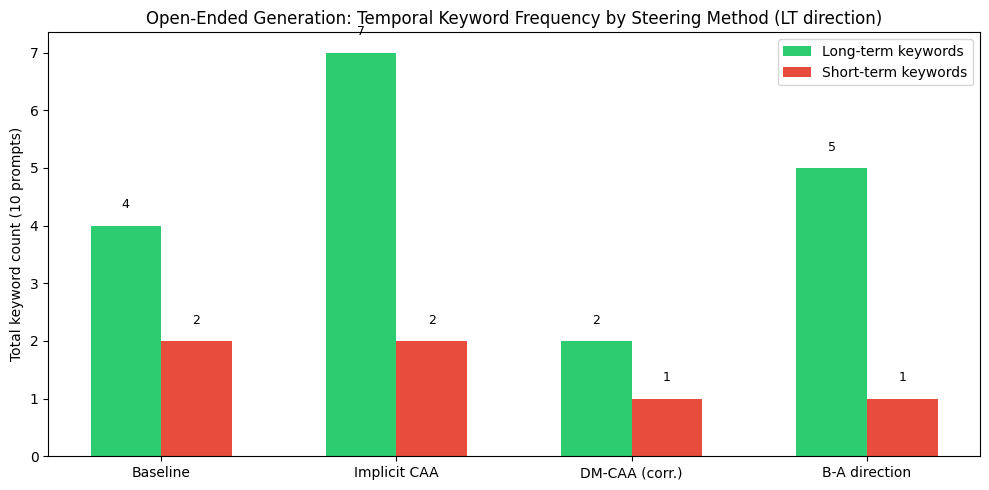

Saved: /content/temporal-awareness/out/experiments/week3_steering/open_ended_keyword_comparison.png
Saved: /content/temporal-awareness/out/experiments/week3_steering/three_way_open_ended_comparison.json


In [65]:
# ── Cell 87 (Section 25) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and BA_RESULTS:
    CMP_PROMPTS = BA_PROMPTS  # the 10 new prompts
    CMP_IMPL_S  = W3_STRENGTHS[-1]   # 11.443
    CMP_DM_S    = DM_STRENGTHS[-1]   # 11.443
    CMP_BA_S    = 8.0

    CMP_CONDITIONS = [
        ('Baseline',        None),
        ('Implicit CAA',    lambda: _make_hooks([W3_STEER_LAYER], +1.0, CMP_IMPL_S)),
        ('DM-CAA (corr.)',  lambda: _make_dm_hooks_corrected([W3_STEER_LAYER], +1.0, CMP_DM_S)),
        ('B-A direction',   lambda: _make_ba_hooks([W3_STEER_LAYER], +1.0, CMP_BA_S)),
    ]

    # ── Generate ────────────────────────────────────────────────────────────
    CMP_RESULTS = []
    total = len(CMP_PROMPTS) * len(CMP_CONDITIONS)
    done = 0
    for pi, prompt_text in enumerate(CMP_PROMPTS):
        entry = {'prompt': prompt_text, 'conditions': {}}
        for label, hook_fn in CMP_CONDITIONS:
            if hook_fn is None:
                text = _generate_with_hooks(prompt_text, [])
            else:
                text = _generate_with_hooks(prompt_text, hook_fn())
            entry['conditions'][label] = text.strip()
            done += 1
            print(f'  [{done:3d}/{total}] prompt={pi+1}  {label}')
        CMP_RESULTS.append(entry)

    print(f'\nThree-way comparison complete: {len(CMP_RESULTS)} prompts × {len(CMP_CONDITIONS)} methods.')

    # ── Display as markdown ─────────────────────────────────────────────────
    for entry in CMP_RESULTS:
        cond = entry['conditions']
        rows = [
            '| Method | Completion |',
            '|--------|------------|',
        ]
        for label, _ in CMP_CONDITIONS:
            rows.append(f'| **{label}** | {_abbrev(cond[label])} |')
        display(Markdown(f"### Prompt: {entry['prompt']}\n\n" + '\n'.join(rows)))
        print()

    # ── Keyword bar chart ───────────────────────────────────────────────────
    methods = [label for label, _ in CMP_CONDITIONS]
    lt_totals = []
    st_totals = []
    for label, _ in CMP_CONDITIONS:
        lt_totals.append(sum(_count_keywords(e['conditions'][label], LT_KEYWORDS) for e in CMP_RESULTS))
        st_totals.append(sum(_count_keywords(e['conditions'][label], ST_KEYWORDS) for e in CMP_RESULTS))

    x = np.arange(len(methods))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - 0.15, lt_totals, 0.3, color='#2ecc71', label='Long-term keywords')
    ax.bar(x + 0.15, st_totals, 0.3, color='#e74c3c', label='Short-term keywords')
    for i in range(len(methods)):
        ax.text(i - 0.15, lt_totals[i] + 0.3, str(lt_totals[i]), ha='center', fontsize=9)
        ax.text(i + 0.15, st_totals[i] + 0.3, str(st_totals[i]), ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=10)
    ax.set_ylabel('Total keyword count (10 prompts)')
    ax.set_title('Open-Ended Generation: Temporal Keyword Frequency by Steering Method (LT direction)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / 'open_ended_keyword_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {W3_OUT_DIR / "open_ended_keyword_comparison.png"}')

    # ── Save JSON ───────────────────────────────────────────────────────────
    _save_path = W3_OUT_DIR / 'three_way_open_ended_comparison.json'
    with open(_save_path, 'w') as f:
        json.dump({
            'results': CMP_RESULTS,
            'strengths': {
                'implicit_caa': CMP_IMPL_S,
                'dm_caa_corrected': CMP_DM_S,
                'ba_direction': CMP_BA_S,
            },
        }, f, indent=2)
    print(f'Saved: {_save_path}')

## Section 26 — Open-Ended Steering Summary

Aggregate statistics across all methods and prompts.  Keyword counting is a coarse
proxy — inspect the tables above for qualitative shifts in planning horizon,
abstraction level, and framing.

In [66]:
# ── Cell 89 (Section 26) ──────────────────────────────────────────────────
if W3_RUN_BINARY_CHOICE and CMP_RESULTS:
    print('=' * 70)
    print('OPEN-ENDED STEERING SUMMARY  (LT direction, 10 prompts)')
    print('=' * 70)
    print(f'{"Method":<20s}  {"LT_kw":>6s}  {"ST_kw":>6s}  {"Ratio":>6s}  {"Avg words":>9s}')
    print('-' * 55)
    for label, _ in CMP_CONDITIONS:
        lt_total = sum(_count_keywords(e['conditions'][label], LT_KEYWORDS) for e in CMP_RESULTS)
        st_total = sum(_count_keywords(e['conditions'][label], ST_KEYWORDS) for e in CMP_RESULTS)
        ratio    = lt_total / max(st_total, 1)
        avg_len  = np.mean([len(e['conditions'][label].split()) for e in CMP_RESULTS])
        print(f'  {label:<20s}  {lt_total:5d}  {st_total:5d}  {ratio:6.2f}  {avg_len:8.0f}')
    print('=' * 70)

    # ── Also summarise B-A sweep (Section 24) with both directions ─────────
    print(f'\n{"=" * 70}')
    print('B-A DIRECTION SWEEP  (all 20 prompts, both directions)')
    print('=' * 70)
    print(f'{"Condition":<14s}  {"LT_kw":>6s}  {"ST_kw":>6s}  {"Ratio":>6s}')
    print('-' * 40)
    for label, _ in BA_CONDITIONS:
        lt_total = sum(_count_keywords(e['conditions'][label], LT_KEYWORDS) for e in BA_RESULTS)
        st_total = sum(_count_keywords(e['conditions'][label], ST_KEYWORDS) for e in BA_RESULTS)
        ratio    = lt_total / max(st_total, 1)
        print(f'  {label:<14s}  {lt_total:5d}  {st_total:5d}  {ratio:6.2f}')
    print('=' * 70)
    print('\nNote: keyword counting is a coarse proxy. Inspect the tables above for')
    print('qualitative shifts in planning horizon, abstraction level, and framing.')


OPEN-ENDED STEERING SUMMARY  (LT direction, 10 prompts)
Method                 LT_kw   ST_kw   Ratio  Avg words
-------------------------------------------------------
  Baseline                  4      2    2.00       102
  Implicit CAA              7      2    3.50       105
  DM-CAA (corr.)            2      1    2.00       100
  B-A direction             5      1    5.00        72

B-A DIRECTION SWEEP  (all 20 prompts, both directions)
Condition        LT_kw   ST_kw   Ratio
----------------------------------------
  baseline            2      1    2.00
  BA_LT_2.0           5      1    5.00
  BA_LT_4.0           3      2    1.50
  BA_LT_8.0           2      1    2.00
  BA_ST_2.0           2      3    0.67
  BA_ST_4.0           1      4    0.25
  BA_ST_8.0           0      2    0.00

Note: keyword counting is a coarse proxy. Inspect the tables above for
qualitative shifts in planning horizon, abstraction level, and framing.
